# Advanced ML and surrogate modelling of process plants
## NeqSim → modular learning → uncertainty → verified decisions

**A reproducible research and teaching notebook · version 1.0 · 22 September 2026**

[Open in Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/notebooks/advanced-ml-surrogates-3819/notebooks/process/advanced_ml_process_surrogates.ipynb)

Build a gas-conditioning plant in **NeqSim**, generate a traceable simulation dataset,
and investigate when machine learning can accelerate engineering decisions. This is an advanced
continuation of [Machine learning and process simulation](Machine_learning_and_process_simulation.ipynb).
All data are synthetic simulations of an explicitly defined mixture and plant. No field calibration
or industrial qualification is implied.

**Research motivation:** [equinor/neqsim#3819](https://github.com/equinor/neqsim/issues/3819)
links MPNet [1], a modular **semiconductor TCAD** surrogate. Its transferable ideas are equipment-level
learning, composition of modules, and management of propagated error. This notebook does not reproduce
MPNet's image-based UNet/attention architecture, training data, or reported semiconductor performance.
It implements a chemical-process analogue and evaluates it on NeqSim-generated data.

**You will execute:** a ten-unit plant; component/energy audits; independent design, validation,
calibration and test experiments; polynomial, tree, neural-network and Gaussian-process models;
conservative modular surrogates; physics-residual and two-fidelity learning; split-conformal intervals;
active sampling; constrained optimization with native replay; a dynamic reduced model; and a guarded
Java/Python inference handoff.

**Runtime:** CPU is sufficient. The default experiment uses hundreds of process evaluations and small
models; allow several minutes after the first Maven build. Every figure is stored inline and as PNG.

## 1. What is state of the art—and what is implemented here?

No architecture is universally best. Choose the representation and validation protocol around the
decision, data volume, physical constraints, and domain shift.

| Approach | Best fit | Main risk | Treatment here |
|---|---|---|---|
| Polynomial / tree baseline | Small tabular designs; quick error diagnosis | Underfit or discontinuous gradients | Executed on common splits |
| Gaussian process (GP) | Expensive simulator; small/medium data | Kernel mismatch; cubic training cost | Matérn GP, uncertainty and active design |
| Deep ensembles | Smooth multivariate mappings | Confident extrapolation; training cost | Three independently initialized MLPs |
| Modular hybrid flowsheet | Reusable equipment and conservation | Interface errors accumulate | Three connected component-split modules |
| Physics-residual model | Useful approximate physical equation | Wrong baseline or nonphysical correction | Ideal-gas compression + learned residual |
| Multi-fidelity learning | Correlated cheap and expensive models | Negative transfer; inconsistent domains | Paired SRK/PR discrepancy experiment |
| Graph neural networks | Variable equipment topology | Need many diverse graphs | Research extension; not trained here |
| PINNs / neural operators | Spatial or transient fields; PDE constraints | Stiffness, boundary and training errors | Scope discussion; not a label for this tabular model |
| LLM / agent tools | Model assembly and investigation | Unsupported numerical claims | Orchestration context only |

MPNet [1] and modular flowsheet work [2] motivate compositional models. Deep ensembles [3] motivate
model diversity; our deterministic MLP ensemble is an illustrative simplification, without a learned
aleatoric variance head. Conformal prediction [4] adds calibration under exchangeability. Neural
operators [5,6] learn mappings between functions; they become relevant for pipe/CFD fields, not simply
because a network has multiple layers. The multi-fidelity review [7] distinguishes model management
from merely fitting more data.

**Evidence boundary:** surrogate accuracy is measured against NeqSim. Conservation supports physical
consistency, but neither good surrogate accuracy nor small balance residuals validate an EOS against
plant measurements. A prospective deployment also needs laboratory/plant validation and uncertainty
in composition, equipment performance, and measurements.

## 2. Clean Colab setup and immutable source provenance

The installation cell uses public PyPI. Java calculations use the source commit that was current
`equinor/neqsim master` when this notebook was authored. Retaining the exact commit makes results
repeatable; change `NEQSIM_SOURCE_REF` deliberately to qualify a newer master.

In Colab the source is cloned and built. An automated validator may provide `NEQSIM_SOURCE_ROOT`
and `NEQSIM_SOURCE_JAR` for the same clean Git commit and built JAR. This still checks the commit,
source cleanliness, JAR hash and actual class location. Restart the kernel before changing the JAR.

In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

REQUIREMENTS = [
    "neqsim==3.20.0",
    "numpy==2.5.3",
    "pandas==3.0.6",
    "scipy==1.18.1",
    "scikit-learn==1.9.1",
    "matplotlib==3.11.2",
    "joblib==1.6.0",
]
is_colab = "google.colab" in sys.modules
if not is_colab and importlib.util.find_spec("google") is not None:
    is_colab = importlib.util.find_spec("google.colab") is not None
if is_colab:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *REQUIREMENTS],
        check=True,
    )
else:
    print("Using the validator's new isolated environment; versions are recorded below.")
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

Using the validator's new isolated environment; versions are recorded below.


In [2]:
import hashlib
import json
import platform
from importlib.metadata import version
from urllib.parse import unquote, urlparse

import jpype

NEQSIM_SOURCE_REF = "65dd8733383d64618fa002ac8137925482093365"
source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-ml-source"))
if not source_root.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--filter=blob:none",
            "--no-checkout",
            "https://github.com/equinor/neqsim.git",
            str(source_root),
        ],
        check=True,
    )
    subprocess.run(["git", "checkout", NEQSIM_SOURCE_REF], cwd=source_root, check=True)
resolved_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    cwd=source_root,
    text=True,
).strip()
assert resolved_commit == NEQSIM_SOURCE_REF, "Source commit differs from the declared revision"
source_changes = subprocess.check_output(
    ["git", "status", "--porcelain", "--", "src/main", "pom.xml"],
    cwd=source_root,
    text=True,
).strip()
assert not source_changes, "Tracked runtime source must be clean"
jar = Path(
    os.environ.get(
        "NEQSIM_SOURCE_JAR",
        str(source_root / "target/neqsim-3.21.0.jar"),
    )
).resolve()
if not jar.exists():
    build = subprocess.run(
        ["bash", "mvnw", "-q", "-DskipTests", "-Dmaven.javadoc.skip=true", "package"],
        cwd=source_root,
        text=True,
        capture_output=True,
    )
    (source_root / "notebook-build.log").write_text(build.stdout + build.stderr)
    if build.returncode:
        raise RuntimeError((build.stdout + build.stderr)[-5000:])
assert jar.is_file()
assert not jpype.isJVMStarted(), "Restart the runtime to prove JAR provenance"
jpype.addClassPath(str(jar))
jpype.startJVM("-Xmx2g", convertStrings=True)
J = jpype.JPackage("neqsim")
main_class = jpype.JClass("neqsim.process.safety.release.SourceTermFrame")
location = str(main_class.class_.getProtectionDomain().getCodeSource().getLocation())
assert Path(unquote(urlparse(location).path)).resolve() == jar
process_class = jpype.JClass("neqsim.process.processmodel.ProcessSystem")
process_location = str(process_class.class_.getProtectionDomain().getCodeSource().getLocation())
assert Path(unquote(urlparse(process_location).path)).resolve() == jar
provenance = {
    "NeqSim commit": resolved_commit,
    "NeqSim JAR SHA256": hashlib.sha256(jar.read_bytes()).hexdigest(),
    "Loaded class location": location,
    "Java": str(jpype.JClass("java.lang.System").getProperty("java.version")),
    "Python": platform.python_version(),
    "packages": {p.split("==")[0]: version(p.split("==")[0]) for p in REQUIREMENTS},
}
print(json.dumps(provenance, indent=2))

{
  "NeqSim commit": "65dd8733383d64618fa002ac8137925482093365",
  "NeqSim JAR SHA256": "105702eb2537873c5bb4448280cdb5df57be51294c0e2af78332eb3ea1747d92",
  "Loaded class location": "file:/workspace/scratch/3821cb0d6e55/neqsim-runtime/target/neqsim-3.21.0.jar",
  "Java": "17.0.20",
  "Python": "3.12.14",
  "packages": {
    "neqsim": "3.20.0",
    "numpy": "2.5.3",
    "pandas": "3.0.6",
    "scipy": "1.18.1",
    "scikit-learn": "1.9.1",
    "matplotlib": "3.11.2",
    "joblib": "1.6.0"
  }
}


In [3]:
import time
import warnings
from dataclasses import dataclass

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from scipy.optimize import differential_evolution
from scipy.special import expit, logit
from scipy.stats import qmc
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from threadpoolctl import threadpool_limits

thread_limit = threadpool_limits(limits=1)
SEED = 3819
rng = np.random.default_rng(SEED)
OUT = Path("neqsim_ml_results")
OUT.mkdir(exist_ok=True)
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "figure.dpi": 115,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
        "savefig.bbox": "tight",
        "axes.prop_cycle": plt.cycler(color=["#176b99", "#e8883a", "#219781", "#9861ad"]),
    }
)
pd.set_option("display.max_columns", 12)
figure_files = []


def save_show(name):
    path = OUT / f"{name}.png"
    plt.savefig(path, dpi=155, bbox_inches="tight")
    figure_files.append(path.name)
    plt.show()
    plt.close()


def show_table(frame, decimals=4):
    display(frame.round(decimals))


print("CPU threads fixed to one for repeatable small-model timing.")

CPU threads fixed to one for repeatable small-model timing.


## 3. Process, composition, controls and study boundary

The synthetic feed is a dry, sweet gas-condensate mixture. It enters at **80 bara, 65 °C**.
An inlet valve and cooler establish the HP separator condition. Gas is compressed in two stages
with intercooling and liquid knockout; export pressure is **120 bara**. Each knockout liquid is
counted separately. All pressures below are absolute. Cooling duties include inlet conditioning.

| Feature | Range | Role |
|---|---:|---|
| Feed mass flow | 12–26 kg/s | Throughput |
| HP separator pressure | 25–45 bara | Control |
| HP separator temperature | 20–45 °C | Control |
| Interstage pressure | 55–80 bara | Control |
| Inter/aftercooler outlet temperature | 18–38 °C | Utility condition |
| Heavy-component richness multiplier | 0.6–1.4 | Feed variation |
| Isentropic compressor efficiency | 0.68–0.82 | Equipment condition |

The multiplier scales ethane through n-hexane relative to the stated base mole fractions, followed
by normalization. It spans one composition family, not arbitrary fluid chemistry. SRK with mixing
rule 2 supplies the primary data; PR is a controlled alternative in the two-fidelity experiment.
No water, electrolyte, acid-gas treatment, hydrate, wax, pressure-dependent efficiency map, surge,
recycle or mechanical sizing is included. Outlet temperatures are specifications, not exchanger-UA
predictions. Those choices keep the ML experiment reproducible and its physical scope clear.

At roughly 20 kg/s and a total pressure ratio around 3.4, compression should require a few MW.
This order-of-magnitude estimate is checked against the computed base case.

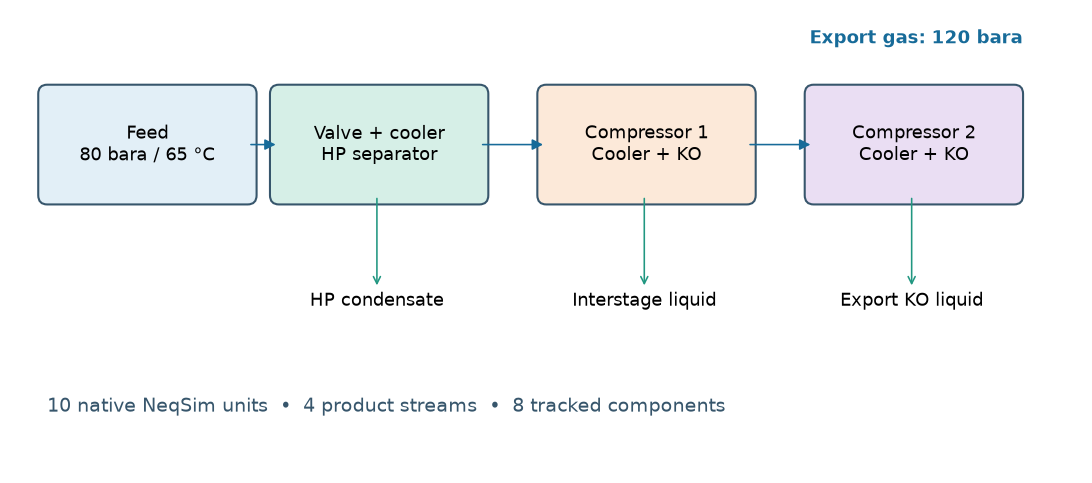

,feature,minimum,nominal,maximum
0,feed_kg_s,12.00,20.00,26.00
1,separator_bara,25.00,35.00,45.00
2,separator_C,20.00,30.00,45.00
3,interstage_bara,55.00,65.00,80.00
4,cooler_C,18.00,28.00,38.00
5,richness,0.60,1.00,1.40
6,efficiency,0.68,0.75,0.82


In [4]:
FEATURES = [
    "feed_kg_s",
    "separator_bara",
    "separator_C",
    "interstage_bara",
    "cooler_C",
    "richness",
    "efficiency",
]
LOW = np.array([12.0, 25.0, 20.0, 55.0, 18.0, 0.6, 0.68])
HIGH = np.array([26.0, 45.0, 45.0, 80.0, 38.0, 1.4, 0.82])
NOMINAL = np.array([20.0, 35.0, 30.0, 65.0, 28.0, 1.0, 0.75])
COMPONENTS = [
    "nitrogen",
    "CO2",
    "methane",
    "ethane",
    "propane",
    "n-butane",
    "n-pentane",
    "n-hexane",
]
BASE_Z = np.array([0.01, 0.02, 0.76, 0.09, 0.06, 0.03, 0.02, 0.01])
TARGETS = ["export_kg_s", "liquid_kg_s", "power_kW", "cooling_kW", "Tmax_C"]
TARGET_UNITS = ["kg/s", "kg/s", "kW", "kW", "°C"]

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis("off")
blocks = [
    (0.4, 3.0, "Feed\n80 bara / 65 °C", "#e2eff7"),
    (3.0, 3.0, "Valve + cooler\nHP separator", "#d6efe7"),
    (6.0, 3.0, "Compressor 1\nCooler + KO", "#fce9d9"),
    (9.0, 3.0, "Compressor 2\nCooler + KO", "#eadef3"),
]
for left, bottom, label, color in blocks:
    ax.add_patch(
        FancyBboxPatch(
            (left, bottom),
            2.25,
            1.1,
            boxstyle="round,pad=0.1",
            facecolor=color,
            edgecolor="#37566c",
            linewidth=1.3,
        )
    )
    ax.text(left + 1.125, bottom + 0.55, label, ha="center", va="center")
for x1, x2 in [(2.65, 3.0), (5.25, 6.0), (8.25, 9.0)]:
    ax.add_patch(
        FancyArrowPatch(
            (x1, 3.55), (x2, 3.55), arrowstyle="-|>", mutation_scale=14, color="#176b99"
        )
    )
for left, label in [
    (3.0, "HP condensate"),
    (6.0, "Interstage liquid"),
    (9.0, "Export KO liquid"),
]:
    ax.annotate(
        label,
        xy=(left + 1.1, 3.0),
        xytext=(left + 1.1, 1.8),
        ha="center",
        arrowprops={"arrowstyle": "<-", "color": "#219781"},
    )
ax.text(10.15, 4.65, "Export gas: 120 bara", ha="center", color="#176b99", weight="bold")
ax.text(
    0.4,
    0.65,
    "10 native NeqSim units  •  4 product streams  •  8 tracked components",
    color="#37566c",
    fontsize=12,
)
save_show("01_flowsheet")
show_table(
    pd.DataFrame({"feature": FEATURES, "minimum": LOW, "nominal": NOMINAL, "maximum": HIGH})
)

The diagram defines the material boundary used throughout the notebook. Every condensate outlet
remains in the balance even when its flow approaches zero. Increasing separator pressure reduces
the downstream pressure ratio but can also change recovery; the optimum is therefore a coupled
thermodynamic and operating-constraint problem.

In [5]:
def composition(richness):
    fractions = BASE_Z.copy()
    fractions[3:] *= richness
    return fractions / fractions.sum()


def component_rates(stream):
    system = stream.getFluid()
    return np.array(
        [
            float(system.getComponent(i).getNumberOfmoles())
            * float(system.getComponent(i).getMolarMass())
            for i in range(len(COMPONENTS))
        ]
    )


def build_plant(x, eos="SRK"):
    flow, pressure, temperature, interstage, cooling, richness, efficiency = map(float, x)
    cls = J.thermo.system.SystemSrkEos if eos == "SRK" else J.thermo.system.SystemPrEos
    fluid = cls(338.15, 80.0)
    for name, fraction in zip(COMPONENTS, composition(richness)):
        fluid.addComponent(name, float(fraction))
    fluid.setMixingRule(2)
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(flow, "kg/sec")
    feed = J.process.equipment.stream.Stream("F-100 feed", fluid)
    valve = J.process.equipment.valve.ThrottlingValve("PV-100 inlet", feed)
    valve.setOutletPressure(pressure)
    inlet_cooler = J.process.equipment.heatexchanger.Cooler(
        "E-100 inlet", valve.getOutletStream()
    )
    inlet_cooler.setOutTemperature(temperature + 273.15)
    separator = J.process.equipment.separator.Separator(
        "V-100 HP", inlet_cooler.getOutletStream()
    )
    units = [feed, valve, inlet_cooler, separator]
    separators = [separator]
    compressors = []
    coolers = [inlet_cooler]
    previous_gas = separator.getGasOutStream()
    for stage, outlet_pressure in enumerate([interstage, 120.0], start=1):
        compressor = J.process.equipment.compressor.Compressor(f"K-{stage}00", previous_gas)
        compressor.setOutletPressure(outlet_pressure)
        compressor.setIsentropicEfficiency(efficiency)
        cooler = J.process.equipment.heatexchanger.Cooler(
            f"E-{stage + 1}00",
            compressor.getOutletStream(),
        )
        cooler.setOutTemperature(cooling + 273.15)
        scrubber = J.process.equipment.separator.Separator(
            f"V-{stage + 1}00", cooler.getOutletStream()
        )
        units.extend([compressor, cooler, scrubber])
        compressors.append(compressor)
        coolers.append(cooler)
        separators.append(scrubber)
        previous_gas = scrubber.getGasOutStream()
    process = J.process.processmodel.ProcessSystem("Gas conditioning and export")
    for unit in units:
        process.add(unit)
    return {
        "process": process,
        "feed": feed,
        "separators": separators,
        "compressors": compressors,
        "coolers": coolers,
        "units": units,
    }


@dataclass
class PlantResult:
    x: np.ndarray
    y: np.ndarray
    feed_components: np.ndarray
    gas_components: np.ndarray
    stage_power: np.ndarray
    stage_temperature: np.ndarray
    stage_cooling: np.ndarray
    mass_error: float
    component_error: float
    energy_error: float
    seconds: float


def simulate(x, eos="SRK", keep_plant=False):
    x = np.asarray(x, dtype=float)
    if x.shape != (7,) or not np.isfinite(x).all():
        raise ValueError("Expected seven finite process inputs")
    if not (x[0] > 0 and 0 < x[6] <= 1 and 0 < x[1] < x[3] < 120):
        raise ValueError("Invalid flow, efficiency, or pressure ordering")
    started = time.perf_counter()
    plant = build_plant(x, eos)
    plant["process"].run()
    feed = plant["feed"]
    separators = plant["separators"]
    liquids = [s.getLiquidOutStream() for s in separators]
    export = separators[-1].getGasOutStream()
    products = liquids + [export]
    flow = float(feed.getFlowRate("kg/sec"))
    feed_components = component_rates(feed)
    gas_components = np.array([component_rates(s.getGasOutStream()) for s in separators])
    product_components = np.array([component_rates(s) for s in products])
    power = np.array([float(c.getPower("kW")) for c in plant["compressors"]])
    temperatures = np.array(
        [float(c.getOutletStream().getTemperature("C")) for c in plant["compressors"]]
    )
    cooling = -np.array([float(c.getDuty()) / 1000 for c in plant["coolers"]])
    mass_error = abs(sum(float(s.getFlowRate("kg/sec")) for s in products) - flow) / flow
    component_error = np.max(abs(product_components.sum(axis=0) - feed_components)) / flow
    enthalpy_in = float(feed.getFluid().getEnthalpy()) / 1000
    enthalpy_out = sum(float(s.getFluid().getEnthalpy()) / 1000 for s in products)
    energy_error = abs(enthalpy_out - enthalpy_in - power.sum() + cooling.sum())
    energy_error /= max(abs(enthalpy_in), abs(enthalpy_out), power.sum(), cooling.sum(), 1.0)
    y = np.array(
        [
            float(export.getFlowRate("kg/sec")),
            sum(float(s.getFlowRate("kg/sec")) for s in liquids),
            power.sum(),
            cooling.sum(),
            temperatures.max(),
        ]
    )
    assert np.isfinite(y).all() and (y[:4] >= -1e-8).all()
    assert mass_error < 1e-7 and component_error < 1e-7
    assert energy_error < 2e-5, f"Energy balance failed: {energy_error}"
    result = PlantResult(
        x,
        y,
        feed_components,
        gas_components,
        power,
        temperatures,
        cooling,
        mass_error,
        component_error,
        energy_error,
        time.perf_counter() - started,
    )
    return (result, plant) if keep_plant else result


base, base_plant = simulate(NOMINAL, keep_plant=True)
show_table(pd.DataFrame({"KPI": TARGETS, "value": base.y, "unit": TARGET_UNITS}))
print("Native units:", int(base_plant["process"].getUnitOperations().size()))
print(
    "Relative residuals (mass, component, energy):",
    base.mass_error,
    base.component_error,
    base.energy_error,
)
assert 500 < base.y[2] < 10000, "Unexpected compression order of magnitude"

Native units: 10
Relative residuals (mass, component, energy): 2.1298518504409004e-13 1.0792478022381147e-13 3.7028163600239885e-10


,KPI,value,unit
0,export_kg_s,18.0636,kg/s
1,liquid_kg_s,1.9364,kg/s
2,power_kW,3219.0069,kW
3,cooling_kW,6594.4952,kW
4,Tmax_C,81.9208,°C


## 4. Conservation, invariance and a local physical benchmark

For component $i$, inlet and product mass rates must close. With heat positive **into** the process
and compressor work positive **into** the fluid, the steady energy balance is

$$\sum_j\dot m_{i,j}^{\mathrm{out}}=\dot m_i^{\mathrm{in}}$$

$$\sum_j\dot H_j^{\mathrm{out}}-\dot H^{\mathrm{in}}=\dot W-\dot Q_{\mathrm{removed}}$$

Mass rates are kg/s; enthalpy, shaft power and heat are kW. The code normalizes the residual by the
largest relevant energy flow. It also tests **extensivity**: with this fixed-efficiency, specified-outlet
model, doubling flow should double rates and duties while preserving temperatures and compositions.
This would not generally hold for a fixed compressor map, finite-UA exchanger or hydraulic network.

,flow multiplier,power kW,max scaling residual,temperature difference °C
0,0.65,2092.354473,0.0,0.0
1,1.00,3219.006881,0.0,0.0
2,1.25,4023.758602,0.0,0.0


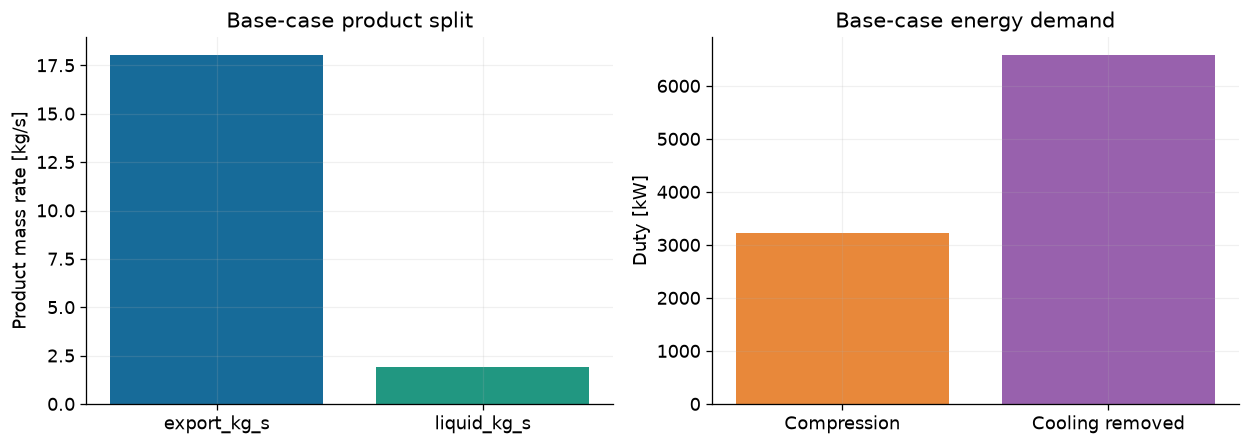

In [6]:
flow_scales = [0.65, 1.0, 1.25]
scale_rows = []
for factor in flow_scales:
    point = NOMINAL.copy()
    point[0] *= factor
    result = simulate(point)
    relative_error = np.max(abs(result.y[:4] / base.y[:4] - factor))
    temperature_error = abs(result.y[4] - base.y[4])
    scale_rows.append([factor, result.y[2], relative_error, temperature_error])
    assert relative_error < 2e-5 and temperature_error < 1e-3
show_table(
    pd.DataFrame(
        scale_rows,
        columns=[
            "flow multiplier",
            "power kW",
            "max scaling residual",
            "temperature difference °C",
        ],
    ),
    decimals=8,
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(TARGETS[:2], base.y[:2], color=["#176b99", "#219781"])
axes[0].set_ylabel("Product mass rate [kg/s]")
axes[0].set_title("Base-case product split")
axes[1].bar(["Compression", "Cooling removed"], base.y[2:4], color=["#e8883a", "#9861ad"])
axes[1].set_ylabel("Duty [kW]")
axes[1].set_title("Base-case energy demand")
fig.tight_layout()
save_show("02_base_case")

The energy plot separates compressor shaft demand from removed heat; their magnitudes need not match
because the feed and products have different enthalpies. The three-point scaling test provides an
independent mathematical check of this specified-equipment model. It is not a compressor vendor
benchmark or an experimental validation of phase equilibrium.

## 5. Experimental design without information leakage

We fit on a space-filling Latin-hypercube design (LHS), choose hyperparameters only with a separate
validation set, and reserve independently sampled uniform calibration and test sets. The latter two
are IID from the same rectangular operating distribution, conditional on successful simulation.
That distinction matters for conformal inference: an LHS design is dependent and should not casually
be described as IID.

A separate stress set extends separator temperature and richness beyond their trained ranges.
It tests **distribution shift**, not just another random split. The seven named inputs are available
before simulation. Post-simulation gas composition is allowed only at a physical module interface;
it is never smuggled into the whole-plant predictor at test time.

Failures are retained with inputs and reasons. No target is replaced with zero, and no failed row is
quietly dropped. This demonstration stops if the defined in-domain design produces invalid cases.

In [7]:
def uniform_design(n, seed):
    generator = np.random.default_rng(seed)
    return LOW + generator.random((n, len(FEATURES))) * (HIGH - LOW)


X_train = qmc.scale(qmc.LatinHypercube(d=7, seed=SEED).random(240), LOW, HIGH)
X_valid = uniform_design(64, SEED + 1)
X_cal = uniform_design(100, SEED + 2)
X_test = uniform_design(120, SEED + 3)
X_ood = uniform_design(60, SEED + 4)
X_ood[:, 2] = np.random.default_rng(SEED + 5).uniform(46.0, 58.0, 60)
X_ood[:, 5] = np.random.default_rng(SEED + 6).uniform(1.45, 1.75, 60)

failures = []


def simulate_design(points, label, eos="SRK"):
    results = []
    for index, point in enumerate(points):
        try:
            results.append(simulate(point, eos=eos))
        except Exception as error:
            failures.append(
                {
                    "set": label,
                    "index": index,
                    "x": point.tolist(),
                    "error": str(error),
                    "eos": eos,
                }
            )
    (OUT / "failed_cases.json").write_text(json.dumps(failures, indent=2))
    if len(results) != len(points):
        raise RuntimeError(f"{label}: inspect {OUT / 'failed_cases.json'} before proceeding")
    return results


started = time.perf_counter()
DATA = {}
for label, points in [
    ("train", X_train),
    ("validation", X_valid),
    ("calibration", X_cal),
    ("test", X_test),
    ("shift", X_ood),
]:
    DATA[label] = simulate_design(points, label)
    print(f"{label}: {len(points)} valid / {len(points)} attempted")
data_seconds = time.perf_counter() - started
Y_train, Y_valid, Y_cal, Y_test, Y_ood = [
    np.array([r.y for r in DATA[label]])
    for label in ["train", "validation", "calibration", "test", "shift"]
]
records = []
for label, results in DATA.items():
    for index, result in enumerate(results):
        records.append(
            {
                "split": label,
                "case": index,
                **dict(zip(FEATURES, result.x)),
                **dict(zip(TARGETS, result.y)),
                "mass_residual": result.mass_error,
                "component_residual": result.component_error,
                "energy_residual": result.energy_error,
                "seconds": result.seconds,
            }
        )
dataset = pd.DataFrame(records)
dataset.to_csv(OUT / "process_dataset.csv", index=False)
balance_summary = dataset.groupby("split").agg(
    cases=("case", "count"),
    max_mass_error=("mass_residual", "max"),
    max_component_error=("component_residual", "max"),
    max_energy_error=("energy_residual", "max"),
    mean_runtime_s=("seconds", "mean"),
)
for column in ["max_mass_error", "max_component_error", "max_energy_error"]:
    balance_summary[column] = balance_summary[column].map(lambda value: f"{value:.2e}")
show_table(balance_summary, decimals=5)
print(f"Data generation: {data_seconds:.1f} s; failures: {len(failures)}")

train: 240 valid / 240 attempted
validation: 64 valid / 64 attempted
calibration: 100 valid / 100 attempted
test: 120 valid / 120 attempted
shift: 60 valid / 60 attempted
Data generation: 29.0 s; failures: 0


,cases,max_mass_error,max_component_error,max_energy_error,mean_runtime_s
split,,,,,
calibration,100,2.23e-12,1.24e-12,4.32e-10,0.04412
shift,60,2.09e-12,8.84e-13,2.67e-10,0.04760
test,120,3.00e-12,1.58e-12,3.91e-10,0.04339
train,240,2.54e-12,1.40e-12,4.07e-10,0.05666
validation,64,1.50e-12,8.85e-13,3.59e-10,0.04481


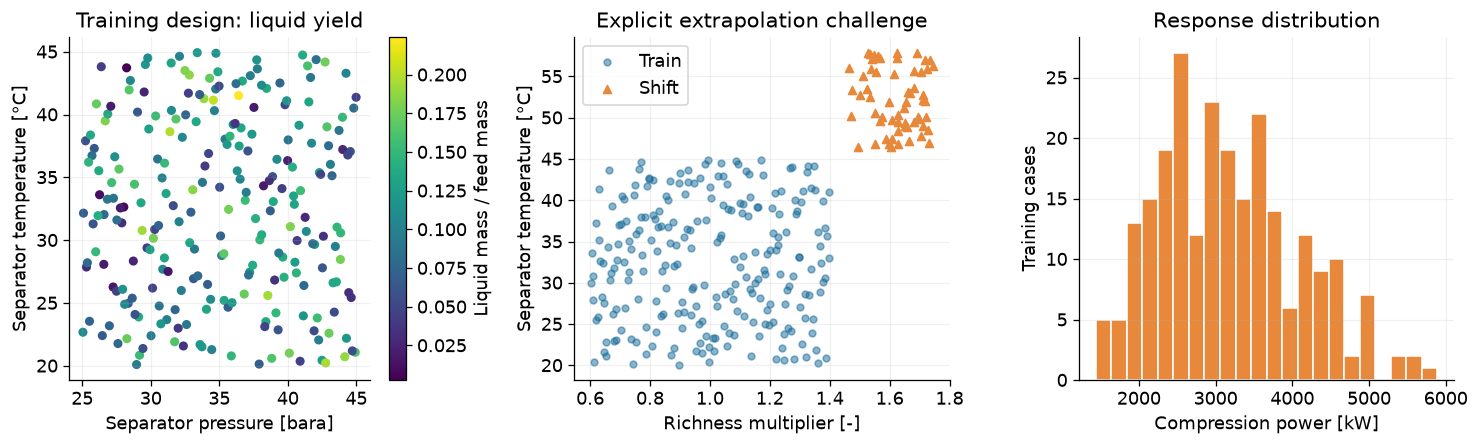

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
scatter = axes[0].scatter(
    X_train[:, 1], X_train[:, 2], c=Y_train[:, 1] / X_train[:, 0], cmap="viridis", s=22
)
axes[0].set(
    xlabel="Separator pressure [bara]",
    ylabel="Separator temperature [°C]",
    title="Training design: liquid yield",
)
fig.colorbar(scatter, ax=axes[0], label="Liquid mass / feed mass")
axes[1].scatter(X_train[:, 5], X_train[:, 2], s=18, alpha=0.5, label="Train")
axes[1].scatter(X_ood[:, 5], X_ood[:, 2], s=25, marker="^", label="Shift")
axes[1].set(
    xlabel="Richness multiplier [-]",
    ylabel="Separator temperature [°C]",
    title="Explicit extrapolation challenge",
)
axes[1].legend()
axes[2].hist(Y_train[:, 2], bins=22, color="#e8883a", edgecolor="white")
axes[2].set(
    xlabel="Compression power [kW]", ylabel="Training cases", title="Response distribution"
)
fig.tight_layout()
save_show("03_design")

The color map shows a projection of a seven-dimensional design, so scattered colors at similar
pressure/temperature are expected: richness and other inputs also vary. The shift set changes two
features together and is intentionally outside the trained rectangle. Its errors must be reported
separately, not averaged into the normal operating score.

## 6. Whole-plant surrogates and physically motivated target scaling

For this plant, mass and energy rates scale with feed flow. We learn **intensive** outputs:
export fraction, liquid fraction, specific power (kJ/kg), specific cooling (kJ/kg), and maximum
compressor discharge temperature (°C). Multiplying rates by flow reconstructs engineering outputs.
Removing an analytically known dependency improves sample efficiency and makes extensivity exact.
The black-box models still predict gas and liquid fractions independently, so mass closure is not
otherwise guaranteed. We measure that defect rather than hide it by normalization.

Training-only standardization prevents leakage. The neural ensemble uses three independently seeded
three-hidden-layer MLPs. Validation chooses ridge strength, tree leaf size, neural regularization and
GP length scale; the test and calibration labels remain untouched during model selection.

In [9]:
INT_COLUMNS = [1, 2, 3, 4, 5, 6]


def intensive_inputs(points):
    points = np.atleast_2d(points)
    return (points[:, INT_COLUMNS] - LOW[INT_COLUMNS]) / (HIGH - LOW)[INT_COLUMNS]


def encode_targets(points, targets):
    values = np.asarray(targets).copy()
    values[:, :4] /= np.atleast_2d(points)[:, :1]
    return values


def decode_targets(points, targets):
    values = np.asarray(targets).copy()
    values[:, :4] *= np.atleast_2d(points)[:, :1]
    return values


Z_train = encode_targets(X_train, Y_train)
Z_valid = encode_targets(X_valid, Y_valid)
response_scale = StandardScaler().fit(Z_train)
scaled_train = response_scale.transform(Z_train)
scaled_valid = response_scale.transform(Z_valid)
train_features = intensive_inputs(X_train)
valid_features = intensive_inputs(X_valid)
fit_seconds = {}
training_warnings = []
models = {}
selection_rows = []

candidates = {
    "Polynomial": [make_pipeline(PolynomialFeatures(2), Ridge(alpha=a)) for a in [0.001, 0.1]],
    "Extra trees": [
        ExtraTreesRegressor(
            n_estimators=180,
            min_samples_leaf=leaf,
            random_state=SEED,
            n_jobs=1,
        )
        for leaf in [1, 3]
    ],
    "MLP": [
        make_pipeline(
            StandardScaler(),
            MLPRegressor(
                hidden_layer_sizes=(48, 48, 24),
                activation="tanh",
                solver="lbfgs",
                alpha=a,
                max_iter=5000,
                max_fun=60000,
                tol=1e-5,
                random_state=SEED,
            ),
        )
        for a in [0.001, 0.03]
    ],
    "GP": [
        GaussianProcessRegressor(
            kernel=ConstantKernel(1.0, constant_value_bounds="fixed")
            * Matern(length_scale=length, length_scale_bounds="fixed", nu=2.5),
            alpha=2e-5,
            optimizer=None,
            normalize_y=False,
        )
        for length in [1.0, 2.0, 3.0]
    ],
}
for name, options in candidates.items():
    scored = []
    started = time.perf_counter()
    for option in options:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            option.fit(train_features, scaled_train)
        training_warnings.extend([f"{name}: {w.message}" for w in caught])
        score = float(np.sqrt(np.mean((option.predict(valid_features) - scaled_valid) ** 2)))
        scored.append((score, option))
    best_score, models[name] = min(scored, key=lambda item: item[0])
    fit_seconds[name] = time.perf_counter() - started
    selection_rows.append([name, best_score, fit_seconds[name]])


def predict_model(name, points):
    standardized = models[name].predict(intensive_inputs(points))
    return decode_targets(points, response_scale.inverse_transform(standardized))


show_table(pd.DataFrame(selection_rows, columns=["model", "validation scaled RMSE", "fit s"]))
print("Training warnings:", training_warnings or "none")

Training warnings: none


,model,validation scaled RMSE,fit s
0,Polynomial,0.1272,0.0038
1,Extra trees,0.3645,0.2639
2,MLP,0.0312,2.0052
3,GP,0.0709,0.0116


In [10]:
ensemble = [models["MLP"]]
best_alpha = models["MLP"].named_steps["mlpregressor"].alpha
started = time.perf_counter()
for seed in [SEED + 20, SEED + 21]:
    member = make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(48, 48, 24),
            activation="tanh",
            solver="lbfgs",
            alpha=best_alpha,
            max_iter=5000,
            max_fun=60000,
            tol=1e-5,
            random_state=seed,
        ),
    )
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        member.fit(train_features, scaled_train)
    training_warnings.extend([f"Ensemble seed {seed}: {w.message}" for w in caught])
    ensemble.append(member)
fit_seconds["Ensemble extra"] = time.perf_counter() - started


def ensemble_predict(points):
    members = np.array(
        [
            decode_targets(
                points, response_scale.inverse_transform(m.predict(intensive_inputs(points)))
            )
            for m in ensemble
        ]
    )
    return members.mean(axis=0), members.std(axis=0, ddof=1)


def metric_rows(label, truth, prediction):
    rows = []
    for index, target in enumerate(TARGETS):
        residual = prediction[:, index] - truth[:, index]
        rows.append(
            {
                "model": label,
                "target": target,
                "MAE": np.mean(abs(residual)),
                "RMSE": np.sqrt(np.mean(residual**2)),
                "P95 absolute error": np.quantile(abs(residual), 0.95),
                "R2": r2_score(truth[:, index], prediction[:, index]),
            }
        )
    return rows


predictions = {name: predict_model(name, X_test) for name in models}
predictions["MLP ensemble"] = ensemble_predict(X_test)[0]
metrics = pd.DataFrame(
    [
        row
        for name, prediction in predictions.items()
        for row in metric_rows(name, Y_test, prediction)
    ]
)
show_table(metrics.pivot(index="model", columns="target", values="RMSE"))
print("RMSE units follow target names; R² and P95 errors are exported in model_metrics.csv.")
metrics.to_csv(OUT / "model_metrics.csv", index=False)

RMSE units follow target names; R² and P95 errors are exported in model_metrics.csv.


target,Tmax_C,cooling_kW,export_kg_s,liquid_kg_s,power_kW
model,,,,,
Extra trees,7.0199,201.2837,0.2369,0.2369,176.6222
GP,1.9547,6.7431,0.0522,0.0522,5.7799
MLP,0.5550,11.1828,0.0298,0.0303,10.7407
MLP ensemble,0.5880,11.3780,0.0314,0.0316,11.9022
Polynomial,2.9222,13.4995,0.1065,0.1065,9.2760


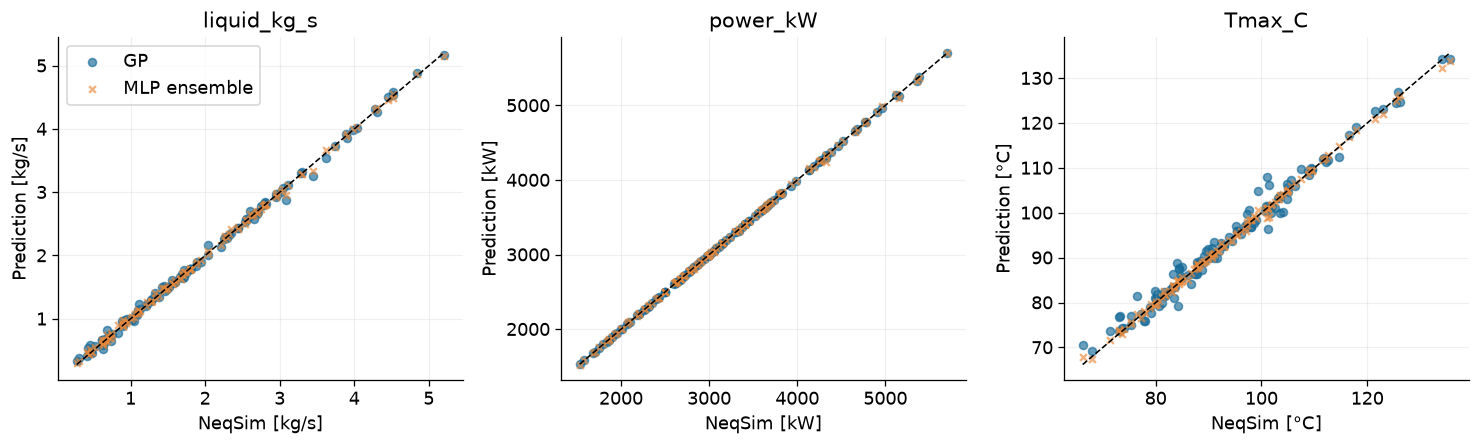

,model,target,MAE,RMSE,P95 absolute error,R2
15,GP,export_kg_s,0.0362,0.0522,0.1114,0.9998
16,GP,liquid_kg_s,0.0362,0.0522,0.1114,0.9980
17,GP,power_kW,3.0045,5.7799,8.5088,1.0000
18,GP,cooling_kW,4.6286,6.7431,12.9120,1.0000
19,GP,Tmax_C,1.3901,1.9547,4.7296,0.9808
20,MLP ensemble,export_kg_s,0.0220,0.0314,0.0685,0.9999
21,MLP ensemble,liquid_kg_s,0.0220,0.0316,0.0687,0.9993
22,MLP ensemble,power_kW,6.7034,11.9022,21.9968,0.9998
23,MLP ensemble,cooling_kW,6.8252,11.3780,23.6264,0.9999
24,MLP ensemble,Tmax_C,0.3942,0.5880,1.2145,0.9983


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for axis, index in zip(axes, [1, 2, 4]):
    axis.scatter(Y_test[:, index], predictions["GP"][:, index], s=25, alpha=0.65, label="GP")
    axis.scatter(
        Y_test[:, index],
        predictions["MLP ensemble"][:, index],
        s=18,
        marker="x",
        alpha=0.65,
        label="MLP ensemble",
    )
    limits = [Y_test[:, index].min(), Y_test[:, index].max()]
    axis.plot(limits, limits, "k--", linewidth=1)
    axis.set(
        xlabel=f"NeqSim [{TARGET_UNITS[index]}]",
        ylabel=f"Prediction [{TARGET_UNITS[index]}]",
        title=TARGETS[index],
    )
axes[0].legend()
fig.tight_layout()
save_show("04_parity")
show_table(metrics[metrics["model"].isin(["GP", "MLP ensemble"])])

Read parity together with RMSE, P95 error and the operating margin. A high R² can coexist with an
unacceptable temperature or power error near a limit. The ensemble is not assumed superior to the
GP: the printed scores determine which method is useful for this dataset. A phase boundary can make
a smooth surrogate less accurate even while the rigorous simulator remains converged.

## 7. A conservative modular plant surrogate

This is the main adaptation of #3819. Each module learns **component gas recoveries** between zero
and one, plus its local work, heat and discharge temperature. The first module represents inlet
conditioning and HP separation; the next two represent compressor–cooler–knockout blocks.

$$\widehat{\dot m}_{i,k}^{g}=r_{i,k}\dot m_{i,k}^{\mathrm{in}},\qquad\widehat{\dot m}_{i,k}^{l}=(1-r_{i,k})\dot m_{i,k}^{\mathrm{in}},\qquad 0\leq r_{i,k}\leq1$$

Here $k$ is a module index, $i$ a component, and $r$ the predicted recovery. These algebraic assignments
conserve each component and preserve nonnegative rates. They do **not** enforce fugacity equilibrium
or energy conservation of independently learned duties. Local inputs are inlet component mass
fractions and local temperatures, pressures and efficiency. Flow enters only through exact scaling.
Extra trees are used for bounded interpolation of recoveries; neural replacements require a bounded
output transform, for example a sigmoid.

Compare **teacher-forced** interfaces (true upstream gas) with the deployed **rollout** (predicted
upstream gas). Only rollout scores represent a usable plant surrogate. MPNet's joint fine-tuning is
an extension, not implemented here; this experiment exposes the error accumulation it aims to reduce.

In [12]:
def local_features(points, inlet, stage):
    points = np.atleast_2d(points)
    total = inlet.sum(axis=1, keepdims=True)
    fraction = inlet / np.maximum(total, 1e-12)
    if stage == 0:
        operating = points[:, [1, 2]] / np.array([40.0, 40.0])
    else:
        pin = points[:, 1] if stage == 1 else points[:, 3]
        pout = points[:, 3] if stage == 1 else np.full(len(points), 120.0)
        tin = points[:, 2] if stage == 1 else points[:, 4]
        operating = np.column_stack(
            [pin / 100.0, pout / 120.0, tin / 40.0, points[:, 4] / 40.0, points[:, 6]]
        )
    return np.column_stack([fraction, operating])


module_models = []
for stage in range(3):
    inlet = np.array(
        [r.feed_components if stage == 0 else r.gas_components[stage - 1] for r in DATA["train"]]
    )
    outlet = np.array([r.gas_components[stage] for r in DATA["train"]])
    recoveries = np.clip(outlet / np.maximum(inlet, 1e-12), 0.0, 1.0)
    local_power = np.array(
        [0.0 if stage == 0 else r.stage_power[stage - 1] for r in DATA["train"]]
    )
    local_temperature = np.array(
        [r.x[2] if stage == 0 else r.stage_temperature[stage - 1] for r in DATA["train"]]
    )
    local_cooling = np.array([r.stage_cooling[stage] for r in DATA["train"]])
    local_targets = np.column_stack(
        [
            recoveries,
            local_power / inlet.sum(axis=1),
            local_cooling / inlet.sum(axis=1),
            local_temperature,
        ]
    )
    scaler = StandardScaler().fit(local_targets)
    model = ExtraTreesRegressor(
        n_estimators=200, min_samples_leaf=1, random_state=SEED + stage, n_jobs=1
    )
    model.fit(local_features(X_train, inlet, stage), scaler.transform(local_targets))
    module_models.append((model, scaler))

molar_masses = np.array(
    [float(base_plant["feed"].getFluid().getComponent(i).getMolarMass()) for i in range(8)]
)


def feed_mass_components(points):
    mole_fractions = np.array([composition(x[5]) for x in points])
    mass_fractions = mole_fractions * molar_masses
    mass_fractions /= mass_fractions.sum(axis=1, keepdims=True)
    return mass_fractions * np.asarray(points)[:, :1]


def modular_predict(points, true_results=None):
    points = np.atleast_2d(points)
    original_feed = feed_mass_components(points)
    inlet = original_feed.copy()
    liquid_sum = np.zeros_like(inlet)
    powers = []
    duties = []
    temperatures = []
    gas_steps = []
    for stage, (model, scaler) in enumerate(module_models):
        if true_results is not None and stage > 0:
            inlet = np.array([r.gas_components[stage - 1] for r in true_results])
        local = scaler.inverse_transform(model.predict(local_features(points, inlet, stage)))
        recovery = np.clip(local[:, :8], 0.0, 1.0)
        gas = inlet * recovery
        liquid_sum += inlet - gas
        powers.append(local[:, 8] * inlet.sum(axis=1))
        duties.append(local[:, 9] * inlet.sum(axis=1))
        if stage > 0:
            temperatures.append(local[:, 10])
        gas_steps.append(gas)
        inlet = gas
    output = np.column_stack(
        [
            gas.sum(axis=1),
            liquid_sum.sum(axis=1),
            np.sum(powers, axis=0),
            np.sum(duties, axis=0),
            np.max(temperatures, axis=0),
        ]
    )
    closure = np.max(abs(original_feed - gas - liquid_sum), axis=1)
    return output, np.array(gas_steps), closure


modular_test, rollout_gas, modular_closure = modular_predict(X_test)
_, teacher_gas, _ = modular_predict(X_test, DATA["test"])
assert modular_closure.max() < 1e-10
modular_metrics = pd.DataFrame(metric_rows("Conservative modules", Y_test, modular_test))
show_table(modular_metrics)
interface_rows = []
for stage in range(3):
    truth = np.array([r.gas_components[stage] for r in DATA["test"]])
    for label, prediction in [("Teacher forced", teacher_gas), ("Rollout", rollout_gas)]:
        interface_rows.append(
            [stage + 1, label, np.sqrt(np.mean((prediction[stage] - truth) ** 2))]
        )
interface_frame = pd.DataFrame(interface_rows, columns=["module", "mode", "component RMSE kg/s"])
show_table(interface_frame)

,model,target,MAE,RMSE,P95 absolute error,R2
0,Conservative modules,export_kg_s,0.0996,0.1335,0.2824,0.9987
1,Conservative modules,liquid_kg_s,0.0996,0.1335,0.2824,0.9866
2,Conservative modules,power_kW,219.3789,295.9856,524.5990,0.8995
3,Conservative modules,cooling_kW,282.8676,373.1894,722.7714,0.9432
4,Conservative modules,Tmax_C,4.4073,6.4244,12.8158,0.7925


,module,mode,component RMSE kg/s
0,1,Teacher forced,0.0178
1,1,Rollout,0.0178
2,2,Teacher forced,0.0213
3,2,Rollout,0.0211
4,3,Teacher forced,0.0000
5,3,Rollout,0.0211


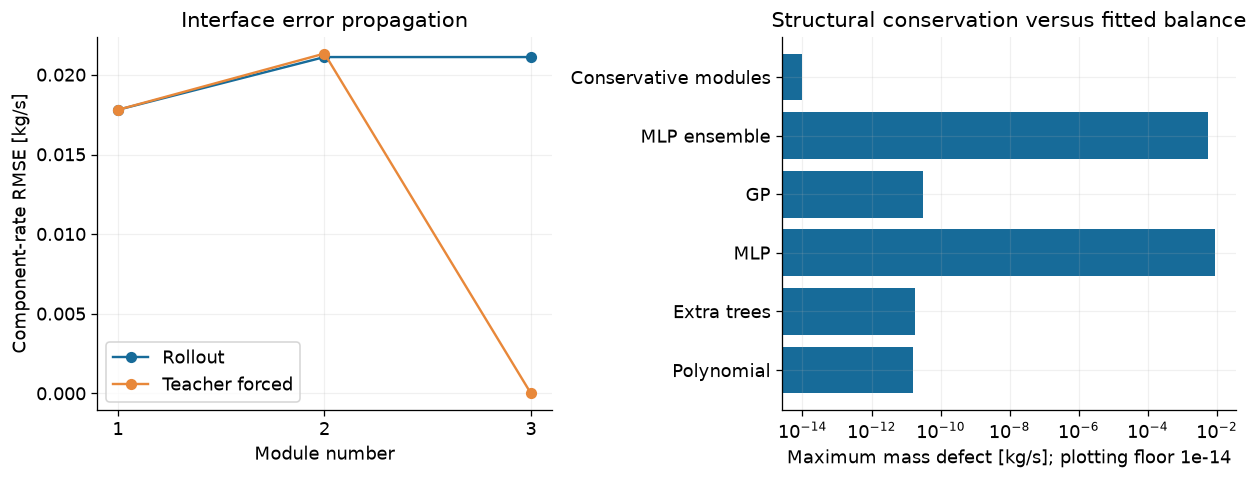

,model,max mass defect kg/s
0,Polynomial,1.531e-11
1,Extra trees,1.824e-11
2,MLP,8.930e-03
3,GP,3.159e-11
4,MLP ensemble,5.423e-03
5,Conservative modules,7.105e-15


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for label, subset in interface_frame.groupby("mode"):
    axes[0].plot(subset["module"], subset["component RMSE kg/s"], "o-", label=label)
axes[0].set(
    xlabel="Module number",
    ylabel="Component-rate RMSE [kg/s]",
    title="Interface error propagation",
    xticks=[1, 2, 3],
)
axes[0].legend()
closure_rows = []
for name, prediction in {**predictions, "Conservative modules": modular_test}.items():
    closure_rows.append([name, np.max(abs(prediction[:, 0] + prediction[:, 1] - X_test[:, 0]))])
closure_frame = pd.DataFrame(closure_rows, columns=["model", "max mass defect kg/s"])
axes[1].barh(closure_frame["model"], np.maximum(closure_frame["max mass defect kg/s"], 1e-14))
axes[1].set(
    xscale="log",
    xlabel="Maximum mass defect [kg/s]; plotting floor 1e-14",
    title="Structural conservation versus fitted balance",
)
fig.tight_layout()
save_show("05_modular")
closure_display = closure_frame.copy()
closure_display["max mass defect kg/s"] = closure_display["max mass defect kg/s"].map(
    lambda value: f"{value:.3e}"
)
show_table(closure_display)

The modular model closes material by construction even when it has appreciable prediction error.
This illustrates why conservation and accuracy are distinct criteria. The interface comparison
quantifies the cost of replacing true upstream states with learned states. Reusing these modules in
a different flowsheet still requires testing whether the new interface states lie within the
local training support; modularity alone does not establish topology transfer.

## 8. Hybrid physics-residual learning

An ideal-gas compression equation gives an inexpensive, interpretable baseline:

$$\dot W_{\mathrm{ideal}}=\sum_{k=1}^{2}\frac{\dot m c_p T_k}{\eta}\left[\left(\frac{P_{k+1}}{P_k}\right)^{(\gamma-1)/\gamma}-1\right]$$

Temperature $T$ is K, $c_p=2.2$ kJ/(kg K), $\gamma=1.28$, and power is kW. The baseline uses total
feed flow and neglects liquid removal, composition dependence and real-gas effects. Those deliberate
approximations create a correction task:

$$\widehat{\dot W}=\dot W_{\mathrm{ideal}}+\dot m\,\widehat{\delta w}(x)$$

The learned residual $\delta w$ has units kJ/kg. It is trained only on the original training cases.
A good residual fit does not repair an invalid extrapolated baseline; test both in-domain and shift.

,set,model,power RMSE kW
0,IID test,Ideal gas,1871.5143
1,IID test,Direct GP,5.7799
2,IID test,Physics + residual,5.4815
3,Shift,Ideal gas,2467.6189
4,Shift,Direct GP,28.1119
5,Shift,Physics + residual,70.6466


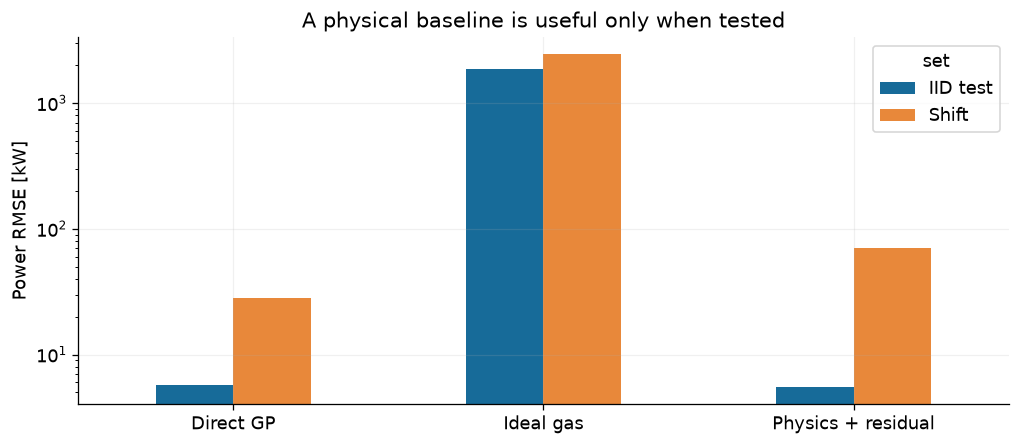

In [14]:
def ideal_power(points):
    points = np.atleast_2d(points)
    ratio1 = points[:, 3] / points[:, 1]
    ratio2 = 120.0 / points[:, 3]
    exponent = (1.28 - 1.0) / 1.28
    rise1 = (points[:, 2] + 273.15) * (ratio1**exponent - 1.0)
    rise2 = (points[:, 4] + 273.15) * (ratio2**exponent - 1.0)
    return points[:, 0] * 2.2 / points[:, 6] * (rise1 + rise2)


residual_gp = GaussianProcessRegressor(
    kernel=Matern(length_scale=2.0, nu=2.5, length_scale_bounds="fixed"),
    alpha=2e-5,
    optimizer=None,
    normalize_y=True,
)
residual_gp.fit(train_features, (Y_train[:, 2] - ideal_power(X_train)) / X_train[:, 0])


def hybrid_power(points):
    return ideal_power(points) + np.atleast_2d(points)[:, 0] * residual_gp.predict(
        intensive_inputs(points)
    )


hybrid_rows = []
for label, points, truth in [("IID test", X_test, Y_test), ("Shift", X_ood, Y_ood)]:
    for name, estimate in [
        ("Ideal gas", ideal_power(points)),
        ("Direct GP", predict_model("GP", points)[:, 2]),
        ("Physics + residual", hybrid_power(points)),
    ]:
        hybrid_rows.append([label, name, np.sqrt(np.mean((estimate - truth[:, 2]) ** 2))])
hybrid_frame = pd.DataFrame(hybrid_rows, columns=["set", "model", "power RMSE kW"])
show_table(hybrid_frame)
fig, ax = plt.subplots(figsize=(9, 4))
hybrid_frame.pivot(index="model", columns="set", values="power RMSE kW").plot.bar(ax=ax)
ax.set(
    yscale="log",
    ylabel="Power RMSE [kW]",
    xlabel="",
    title="A physical baseline is useful only when tested",
)
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
save_show("06_hybrid")

Compare the correction model with both the uncorrected equation and the direct GP. If the corrected
model is worse on the shifted set, that is negative evidence for this particular extrapolation,
not a reason to remove the test. The approximate equation deliberately contains physical bias;
it is an interpretable feature of the experiment rather than a reference truth.

## 9. Calibrated uncertainty, simultaneous outputs and domain shift

Ensemble spread and GP posterior standard deviation are model-dependent uncertainty indicators.
They do not automatically include EOS discrepancy, sensor noise or all interpolation errors. We
calibrate GP intervals using a separate IID set. Define a fixed positive scale $s_j(x)$ from GP
standard deviation with a training-based floor, then use the **maximum across all five outputs**:

$$a_i=\max_j\frac{|y_{ij}-\widehat y_j(x_i)|}{s_j(x_i)}$$

$$q=a_{(\lceil(n_{\mathrm{cal}}+1)(1-\alpha)\rceil)},\qquad C_j(x)=[\widehat y_j(x)-q s_j(x),\widehat y_j(x)+q s_j(x)]$$

The parenthesized subscript means the sorted order statistic; $\alpha=0.1$ targets 90% simultaneous
coverage of the five-output vector for a new exchangeable case. We use the finite-sample rank,
not a naively interpolated percentile. The calibration labels are not used for fitting or tuning.
The guarantee is marginal over the operating distribution, not pointwise, not an optimizer-selected
safety guarantee, and not valid automatically under shift. Coverage is shown with sample counts.

Finite-sample calibration rank 91/100; q=12.476
IID empirical coverage Wilson 95% interval: (np.float64(0.7753231505975375), np.float64(0.9029626596633118))
Uncalibrated ensemble power ±1.96 spread covers 72.5%.
That raw spread has no nominal frequentist coverage guarantee.


,set,n,jointly covered,joint coverage,mean power half-width kW
0,IID test,120,102,0.8500,122.4817
1,Shift,60,56,0.9333,609.0034


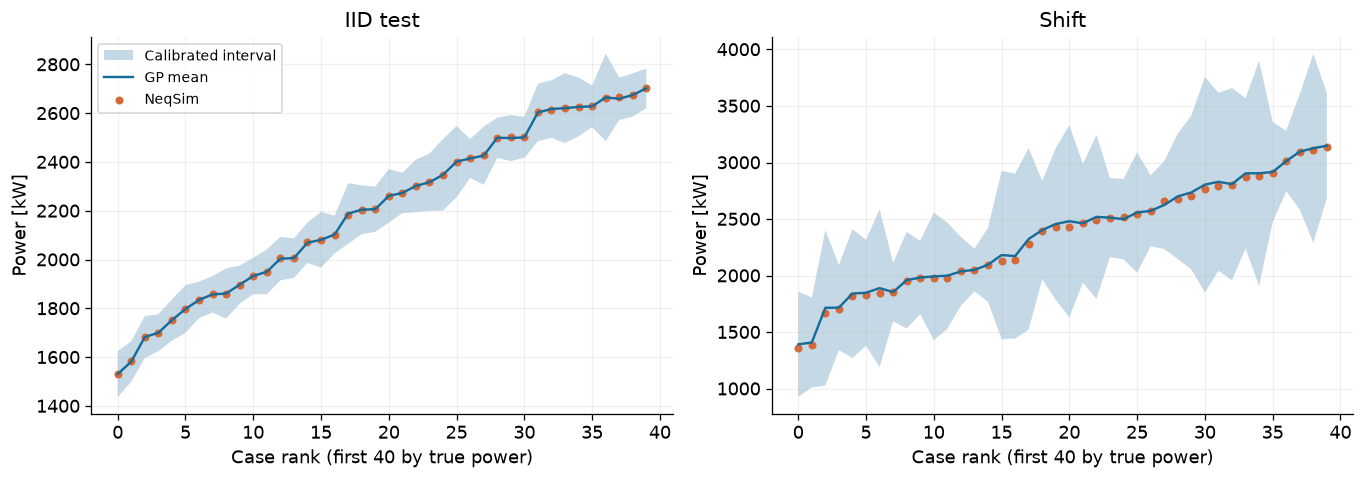

In [15]:
def gp_mean_scale(points):
    points = np.atleast_2d(points)
    mean_z, std_z = models["GP"].predict(intensive_inputs(points), return_std=True)
    if std_z.ndim == 1:
        std_z = np.repeat(std_z[:, None], len(TARGETS), axis=1)
    mean = decode_targets(points, response_scale.inverse_transform(mean_z))
    scale = std_z * response_scale.scale_
    scale = np.maximum(scale, 0.015 * response_scale.scale_[None, :])
    scale[:, :4] *= points[:, :1]
    return mean, scale


ALPHA = 0.10
cal_mean, cal_scale = gp_mean_scale(X_cal)
cal_scores = np.max(abs(Y_cal - cal_mean) / cal_scale, axis=1)
rank = int(np.ceil((len(cal_scores) + 1) * (1 - ALPHA)))
assert rank <= len(cal_scores)
conformal_q = float(np.sort(cal_scores)[rank - 1])
coverage_rows = []
intervals = {}
for label, points, truth in [("IID test", X_test, Y_test), ("Shift", X_ood, Y_ood)]:
    mean, scale = gp_mean_scale(points)
    half_width = conformal_q * scale
    included = abs(truth - mean) <= half_width
    joint = included.all(axis=1)
    coverage_rows.append(
        [label, len(points), int(joint.sum()), joint.mean(), half_width[:, 2].mean()]
    )
    intervals[label] = (mean, half_width)
coverage = pd.DataFrame(
    coverage_rows,
    columns=[
        "set",
        "n",
        "jointly covered",
        "joint coverage",
        "mean power half-width kW",
    ],
)
show_table(coverage)
print(f"Finite-sample calibration rank {rank}/{len(cal_scores)}; q={conformal_q:.3f}")
# Wilson interval describes finite test-count uncertainty, not model confidence.
test_coverage = float(coverage.iloc[0]["joint coverage"])
test_count = int(coverage.iloc[0]["n"])
z_score = 1.96
wilson_center = test_coverage + z_score**2 / (2 * test_count)
wilson_center /= 1 + z_score**2 / test_count
wilson_radius = (
    z_score
    * np.sqrt(test_coverage * (1 - test_coverage) / test_count + z_score**2 / (4 * test_count**2))
    / (1 + z_score**2 / test_count)
)
print(
    "IID empirical coverage Wilson 95% interval:",
    (wilson_center - wilson_radius, wilson_center + wilson_radius),
)
ensemble_mean, ensemble_spread = ensemble_predict(X_test)
raw_ensemble_coverage = np.mean(
    abs(Y_test[:, 2] - ensemble_mean[:, 2]) <= 1.96 * ensemble_spread[:, 2]
)
print(f"Uncalibrated ensemble power ±1.96 spread covers {raw_ensemble_coverage:.1%}.")
print("That raw spread has no nominal frequentist coverage guarantee.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for ax, label, truth in zip(axes, ["IID test", "Shift"], [Y_test, Y_ood]):
    mean, width = intervals[label]
    order = np.argsort(truth[:, 2])[:40]
    position = np.arange(len(order))
    ax.fill_between(
        position,
        mean[order, 2] - width[order, 2],
        mean[order, 2] + width[order, 2],
        alpha=0.25,
        label="Calibrated interval",
    )
    ax.plot(position, mean[order, 2], label="GP mean")
    ax.scatter(position, truth[order, 2], s=16, color="#d56837", label="NeqSim")
    ax.set(title=label, xlabel="Case rank (first 40 by true power)", ylabel="Power [kW]")
axes[0].legend(fontsize=9)
fig.tight_layout()
save_show("07_uncertainty")

The table reports simultaneous coverage, while the plot displays the power coordinate only. A small
sample can land above or below the nominal 90%; inspect the count as well as the percentage. The
shift experiment deliberately breaks the calibration distribution. Large or narrow intervals there
are diagnostics, not qualified protection for a new operating regime.

## 10. Active learning with an equal simulator budget

A space-filling initial design is augmented by points where a GP is most uncertain. At each round,
select a batch greedily using a kernel-distance diversity penalty; run NeqSim **only for selected
points**; then retrain. This is an illustrative uncertainty sampler, not expected-improvement Bayesian
optimization. It reduces global prediction error rather than directly optimizing the plant.

Compare against random acquisition with exactly the same initial design and number of added labels.
The untouched test set is scored after each round and is never used for acquisition. This default
run is a single-seed experiment; multiple acquisition seeds are necessary before claiming a
statistically robust advantage.

Additional NeqSim evaluations: 72


,strategy,labelled cases,power RMSE kW
0,Uncertainty + diversity,40,42.2142
1,Uncertainty + diversity,52,34.6532
2,Uncertainty + diversity,64,27.4725
3,Uncertainty + diversity,76,22.5425
4,Random,40,42.2142
5,Random,52,38.5254
6,Random,64,30.5781
7,Random,76,27.4281


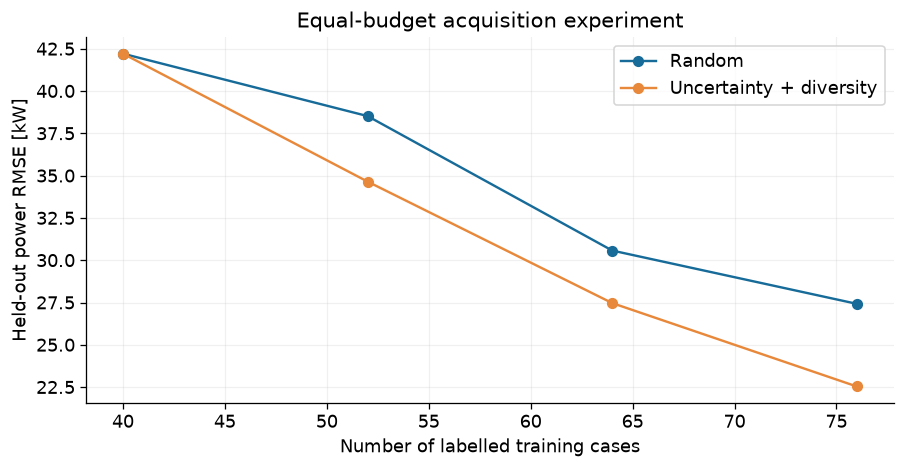

In [16]:
active_pool = uniform_design(400, SEED + 30)
initial_indices = np.arange(40)
initial_x = X_train[initial_indices]
initial_y = Y_train[initial_indices, 2]


def scalar_gp(points, power):
    gp = GaussianProcessRegressor(
        kernel=Matern(length_scale=2.0, length_scale_bounds="fixed", nu=2.5),
        alpha=2e-5,
        optimizer=None,
        normalize_y=True,
    )
    gp.fit(intensive_inputs(points), power / points[:, 0])
    return gp


active_rows = []
acquisition_points = {}
active_simulation_calls = 0
for strategy in ["Uncertainty + diversity", "Random"]:
    selected_x = initial_x.copy()
    selected_y = initial_y.copy()
    available = np.ones(len(active_pool), dtype=bool)
    acquired = []
    random_generator = np.random.default_rng(SEED + 31)
    for round_index in range(4):
        gp = scalar_gp(selected_x, selected_y)
        estimate = gp.predict(intensive_inputs(X_test)) * X_test[:, 0]
        active_rows.append(
            [strategy, len(selected_x), np.sqrt(np.mean((estimate - Y_test[:, 2]) ** 2))]
        )
        if round_index == 3:
            break
        candidates_index = np.flatnonzero(available)
        if strategy == "Random":
            chosen = random_generator.choice(candidates_index, 12, replace=False)
        else:
            features = intensive_inputs(active_pool[candidates_index])
            _, deviation = gp.predict(features, return_std=True)
            acquisition = deviation.copy()
            local_chosen = []
            for _ in range(12):
                index = int(np.argmax(acquisition))
                local_chosen.append(index)
                distances = np.linalg.norm(features - features[index], axis=1)
                acquisition *= 1.0 - np.exp(-((distances / 0.35) ** 2))
                acquisition[local_chosen] = -np.inf
            chosen = candidates_index[local_chosen]
        new_x = active_pool[chosen]
        new_results = simulate_design(new_x, f"active-{strategy}-{round_index}")
        active_simulation_calls += len(new_x)
        selected_x = np.vstack([selected_x, new_x])
        selected_y = np.r_[selected_y, [r.y[2] for r in new_results]]
        available[chosen] = False
        acquired.extend(chosen.tolist())
    acquisition_points[strategy] = acquired
active_frame = pd.DataFrame(active_rows, columns=["strategy", "labelled cases", "power RMSE kW"])
show_table(active_frame)
print("Additional NeqSim evaluations:", active_simulation_calls)
fig, ax = plt.subplots(figsize=(8, 4.2))
for strategy, subset in active_frame.groupby("strategy"):
    ax.plot(subset["labelled cases"], subset["power RMSE kW"], "o-", label=strategy)
ax.set(
    xlabel="Number of labelled training cases",
    ylabel="Held-out power RMSE [kW]",
    title="Equal-budget acquisition experiment",
)
ax.legend()
fig.tight_layout()
save_show("08_active_learning")

Each learning curve includes 40 initial labels and three batches of 12. Do not infer that uncertainty
sampling must win: the kernel and diversity heuristic may target regions that contribute little to
average error. A larger study should repeat the initial design and acquisition seeds, compare
wall-clock costs, and include boundary-focused sampling for active constraints.

## 11. Two-fidelity discrepancy learning: SRK → PR

We use two cubic EOS formulations to demonstrate paired discrepancy modelling:

$$\widehat y_{\mathrm{PR}}(x)=\widehat y_{\mathrm{SRK}}(x)+\widehat\delta(x),\qquad\delta(x)=y_{\mathrm{PR}}(x)-y_{\mathrm{SRK}}(x)$$

This is **additive discrepancy learning**, not a complete autoregressive co-kriging implementation.
PR is designated the target model for this numerical experiment; it is neither automatically more
accurate than SRK nor substantially more expensive. This example demonstrates the workflow, not
an economic claim of cheaper high-fidelity data. Real multi-fidelity studies could pair a cubic EOS
with a qualified association model, simplified equipment with detailed rate-based equipment, or
steady screening with dynamic simulation.

Forty-eight paired training cases fit the discrepancy. Thirty-two separate PR test simulations
compare it with a PR-only GP trained on those same 48 target-model labels. The SRK-assisted method
also uses the 240 original SRK labels, which must be counted in its total cost.

,model,power RMSE vs PR kW
0,SRK GP,101.6917
1,PR-only GP (48),26.1612
2,SRK GP + paired discrepancy,3.4064


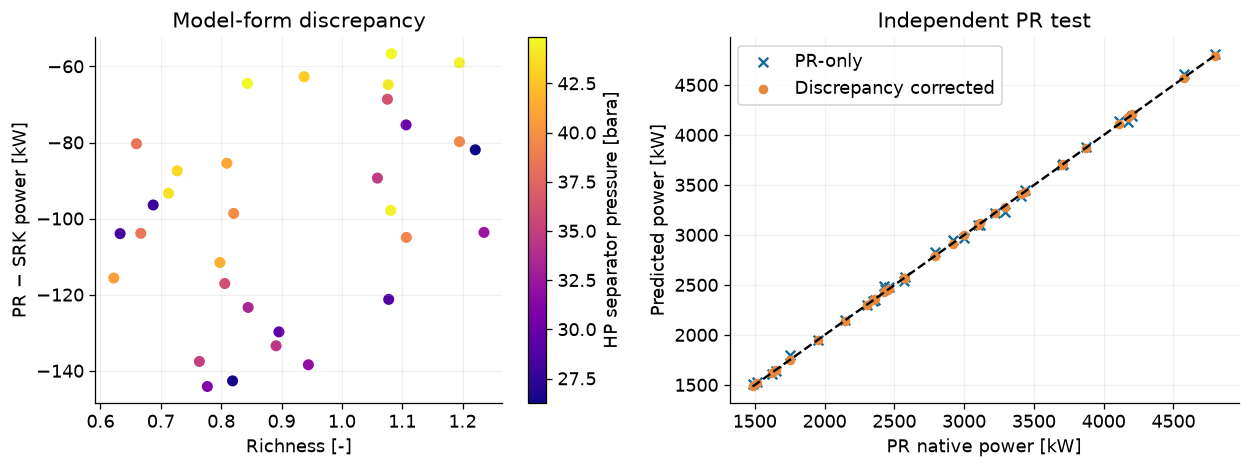

In [17]:
paired_indices = np.random.default_rng(SEED + 40).choice(len(X_train), 48, replace=False)
X_pair = X_train[paired_indices]
pr_train = simulate_design(X_pair, "PR paired training", eos="PR")
X_pr_test = uniform_design(32, SEED + 41)
pr_test = simulate_design(X_pr_test, "PR independent test", eos="PR")
srk_pr_test = simulate_design(X_pr_test, "SRK fidelity comparison")
pr_train_power = np.array([r.y[2] for r in pr_train])
pr_truth = np.array([r.y[2] for r in pr_test])
discrepancy = (pr_train_power - Y_train[paired_indices, 2]) / X_pair[:, 0]
delta_gp = GaussianProcessRegressor(
    kernel=Matern(length_scale=2.0, length_scale_bounds="fixed", nu=2.5),
    alpha=2e-5,
    optimizer=None,
    normalize_y=True,
).fit(intensive_inputs(X_pair), discrepancy)
pr_only = scalar_gp(X_pair, pr_train_power)
srk_prediction = predict_model("GP", X_pr_test)[:, 2]
corrected = srk_prediction + X_pr_test[:, 0] * delta_gp.predict(intensive_inputs(X_pr_test))
pr_only_prediction = pr_only.predict(intensive_inputs(X_pr_test)) * X_pr_test[:, 0]
fidelity_rows = []
for label, estimate in [
    ("SRK GP", srk_prediction),
    ("PR-only GP (48)", pr_only_prediction),
    ("SRK GP + paired discrepancy", corrected),
]:
    fidelity_rows.append([label, np.sqrt(np.mean((estimate - pr_truth) ** 2))])
show_table(pd.DataFrame(fidelity_rows, columns=["model", "power RMSE vs PR kW"]))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
true_difference = pr_truth - np.array([r.y[2] for r in srk_pr_test])
fidelity_scatter = axes[0].scatter(
    X_pr_test[:, 5],
    true_difference,
    c=X_pr_test[:, 1],
    cmap="plasma",
    s=35,
)
fig.colorbar(fidelity_scatter, ax=axes[0], label="HP separator pressure [bara]")
axes[0].set(xlabel="Richness [-]", ylabel="PR − SRK power [kW]", title="Model-form discrepancy")
axes[1].scatter(pr_truth, pr_only_prediction, marker="x", label="PR-only")
axes[1].scatter(pr_truth, corrected, s=25, label="Discrepancy corrected")
limits = [pr_truth.min(), pr_truth.max()]
axes[1].plot(limits, limits, "k--")
axes[1].set(
    xlabel="PR native power [kW]", ylabel="Predicted power [kW]", title="Independent PR test"
)
axes[1].legend()
fig.tight_layout()
save_show("09_multifidelity")

The left panel measures EOS disagreement; the right panel measures approximation of the chosen PR
reference. Neither is an uncertainty bound on the real plant. A residual surrogate can improve data
efficiency when the two models correlate, but can hurt if their phase regimes or equipment definitions
differ. The displayed test scores expose either outcome.

## 12. Explainability, extrapolation and a fail-closed domain gate

Permutation importance is computed on validation data and expressed as the increase in a scaled
error. It is predictive importance, not causality. Correlated or interchangeable inputs can share
importance. A pressure-response slice holds other variables fixed and checks the surrogate against
fresh NeqSim evaluations, exposing the local physics more directly.

A rectangular domain check is necessary but not sufficient. We also compute nearest-training-point
distance in normalized intensive coordinates. The distance threshold is the 95th percentile of
training leave-one-out distances; it is a support heuristic, not a calibrated probability of safety.
Nonfinite or malformed requests are rejected rather than passed to the simulator.

Distance threshold: 0.4455972408153839
Accepted IID / shift requests: 117 / 120 ; 0 / 60


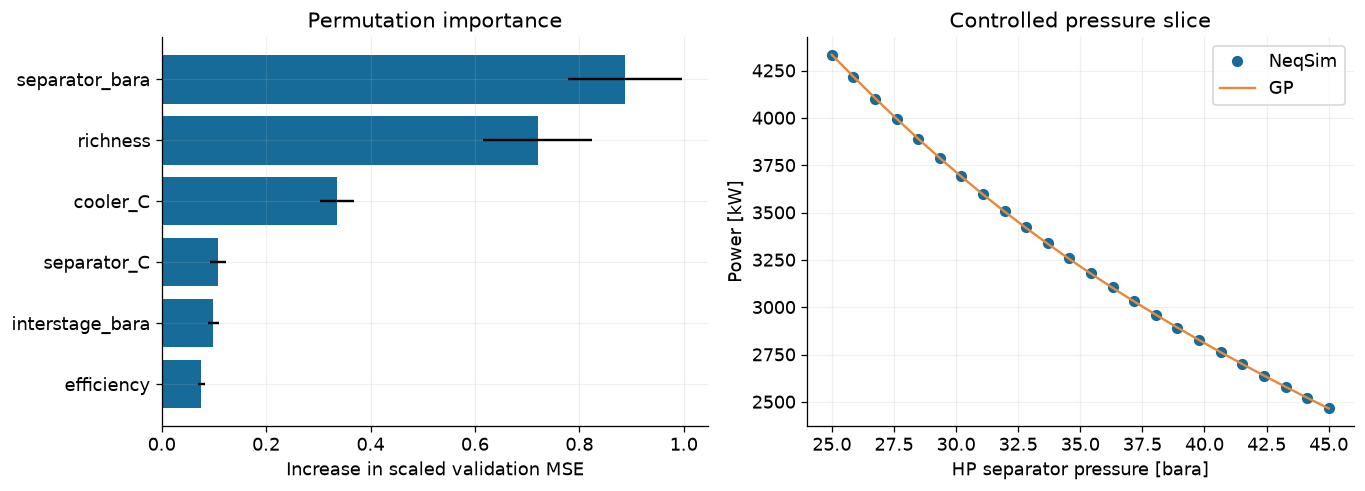

In [18]:
base_score = np.mean((models["GP"].predict(valid_features) - scaled_valid) ** 2)
importance_rows = []
for feature_index, name in enumerate(np.array(FEATURES)[INT_COLUMNS]):
    increases = []
    for repeat in range(8):
        shuffled = valid_features.copy()
        order = np.random.default_rng(SEED + 100 + repeat).permutation(len(shuffled))
        shuffled[:, feature_index] = shuffled[order, feature_index]
        increases.append(
            np.mean((models["GP"].predict(shuffled) - scaled_valid) ** 2) - base_score
        )
    importance_rows.append([name, np.mean(increases), np.std(increases)])
importance = pd.DataFrame(importance_rows, columns=["feature", "MSE increase", "repeat SD"])
nearest = NearestNeighbors(n_neighbors=2).fit(train_features)
training_distances = nearest.kneighbors(train_features)[0][:, 1]
distance_limit = float(np.quantile(training_distances, 0.95))


def domain_gate(points):
    points = np.atleast_2d(np.asarray(points, dtype=float))
    if points.shape[1] != 7 or not np.isfinite(points).all():
        raise ValueError("Seven finite values required")
    bounds_ok = ((points >= LOW) & (points <= HIGH)).all(axis=1)
    distance = nearest.kneighbors(intensive_inputs(points), n_neighbors=1)[0][:, 0]
    return bounds_ok & (distance <= distance_limit), distance


pressure_slice = np.tile(NOMINAL, (24, 1))
pressure_slice[:, 1] = np.linspace(25.0, 45.0, len(pressure_slice))
slice_results = simulate_design(pressure_slice, "pressure interpretation")
slice_truth = np.array([r.y for r in slice_results])
slice_prediction = predict_model("GP", pressure_slice)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ordered = importance.sort_values("MSE increase")
axes[0].barh(ordered["feature"], ordered["MSE increase"], xerr=ordered["repeat SD"])
axes[0].set(xlabel="Increase in scaled validation MSE", title="Permutation importance")
axes[1].plot(pressure_slice[:, 1], slice_truth[:, 2], "o", label="NeqSim")
axes[1].plot(pressure_slice[:, 1], slice_prediction[:, 2], label="GP")
axes[1].set(
    xlabel="HP separator pressure [bara]", ylabel="Power [kW]", title="Controlled pressure slice"
)
axes[1].legend()
fig.tight_layout()
save_show("10_interpretation")
print("Distance threshold:", distance_limit)
print(
    "Accepted IID / shift requests:",
    domain_gate(X_test)[0].sum(),
    "/",
    len(X_test),
    ";",
    domain_gate(X_ood)[0].sum(),
    "/",
    len(X_ood),
)

The pressure slice is a fresh physical check with fixed composition, throughput and efficiency.
Increasing separator pressure normally reduces compression duty here, while liquid recovery and
feed-cooling duty also change. Permutation importance should guide investigation, not justify
changing an operating variable without a counterfactual calculation.

## 13. Surrogate-assisted constrained throughput optimization

Decision variables are feed flow, HP separator pressure and interstage pressure. Other inputs are
fixed at the base case. Maximize feed throughput subject to **illustrative study limits**:
3.0 MW shaft power, 115 °C maximum discharge temperature, and at least 0.65 kg/s condensate recovery.
These are teaching constraints, not equipment ratings or a surge envelope.

$$\max_x\dot m_{\mathrm{feed}}\quad\mathrm{subject\ to}\quad\widehat W+q s_W\leq W_{\max},\quad\widehat T+q s_T\leq T_{\max},\quad\widehat L-q s_L\geq L_{\min}$$

Use calibrated margins to screen conservatively, then **re-run NeqSim for every shortlisted
recommendation**. Adaptive selection invalidates a naive pointwise interpretation of conformal
coverage. Native replay checks these model constraints, not unmodelled physical hazards. A failed
replay is rejected. The continuation reduces flow and replays again before accepting a revised
point; a production optimizer would also enrich the local training data.

In [19]:
POWER_LIMIT = 3000.0
TEMPERATURE_LIMIT = 115.0
LIQUID_MINIMUM = 0.65


def decision_to_x(decision):
    point = NOMINAL.copy()
    point[[0, 1, 3]] = decision
    return point


def screening_objective(decision, use_margin):
    point = decision_to_x(decision)
    supported, _ = domain_gate(point)
    if not supported[0]:
        return 1e6
    mean, scale = gp_mean_scale(point)
    margin = conformal_q * scale[0] if use_margin else np.zeros(5)
    prediction = mean[0]
    violations = np.maximum(
        [
            (prediction[2] + margin[2] - POWER_LIMIT) / 100.0,
            (prediction[4] + margin[4] - TEMPERATURE_LIMIT) / 5.0,
            (LIQUID_MINIMUM - prediction[1] + margin[1]) / 0.1,
        ],
        0.0,
    )
    return -point[0] + 1e4 * np.sum(violations**2)


optimization_rows = []
recommended = {}
for label, margin_enabled in [("Point prediction", False), ("Calibrated margin", True)]:
    optimized = differential_evolution(
        lambda decision: screening_objective(decision, margin_enabled),
        bounds=[(12.0, 26.0), (25.0, 45.0), (55.0, 80.0)],
        seed=SEED,
        popsize=10,
        maxiter=55,
        tol=1e-5,
        polish=False,
        workers=1,
    )
    point = decision_to_x(optimized.x)
    native = simulate(point)
    predicted, scale = gp_mean_scale(point)
    feasible = bool(
        native.y[2] <= POWER_LIMIT
        and native.y[4] <= TEMPERATURE_LIMIT
        and native.y[1] >= LIQUID_MINIMUM
    )
    recommended[label] = (point, native, feasible)
    optimization_rows.append(
        {
            "method": label,
            "feed kg/s": point[0],
            "separator bara": point[1],
            "interstage bara": point[3],
            "predicted kW": predicted[0, 2],
            "native kW": native.y[2],
            "native Tmax °C": native.y[4],
            "native liquid kg/s": native.y[1],
            "native feasible": feasible,
            "screen evaluations": optimized.nfev,
        }
    )
optimization = pd.DataFrame(optimization_rows)
show_table(optimization, decimals=3)
print("All recommendations above have been independently replayed in NeqSim.")
print("Only rows with native feasible=True may proceed to the next engineering assessment.")
accepted_rows = []
for label, (point, native, feasible) in recommended.items():
    candidate = point.copy()
    attempts = 1
    while not feasible and attempts < 8:
        candidate[0] *= 0.98
        native = simulate(candidate)
        feasible = bool(
            native.y[2] <= POWER_LIMIT
            and native.y[4] <= TEMPERATURE_LIMIT
            and native.y[1] >= LIQUID_MINIMUM
        )
        attempts += 1
    accepted_rows.append([label, candidate[0], native.y[2], feasible, attempts])
accepted_frame = pd.DataFrame(
    accepted_rows,
    columns=[
        "method",
        "accepted feed kg/s",
        "replayed power kW",
        "accepted",
        "native replay calls",
    ],
)
show_table(accepted_frame, decimals=3)
assert accepted_frame["accepted"].all(), "No feasible revised point: stop and enrich the model"

All recommendations above have been independently replayed in NeqSim.
Only rows with native feasible=True may proceed to the next engineering assessment.


,method,feed kg/s,separator bara,interstage bara,predicted kW,native kW,native Tmax °C,native liquid kg/s,native feasible,screen evaluations
0,Point prediction,24.512,45.0,74.222,3000.004,2999.739,72.176,2.377,True,1680
1,Calibrated margin,23.336,45.0,73.951,2856.083,2855.825,71.861,2.267,True,1680


,method,accepted feed kg/s,replayed power kW,accepted,native replay calls
0,Point prediction,24.512,2999.739,True,1
1,Calibrated margin,23.336,2855.825,True,1


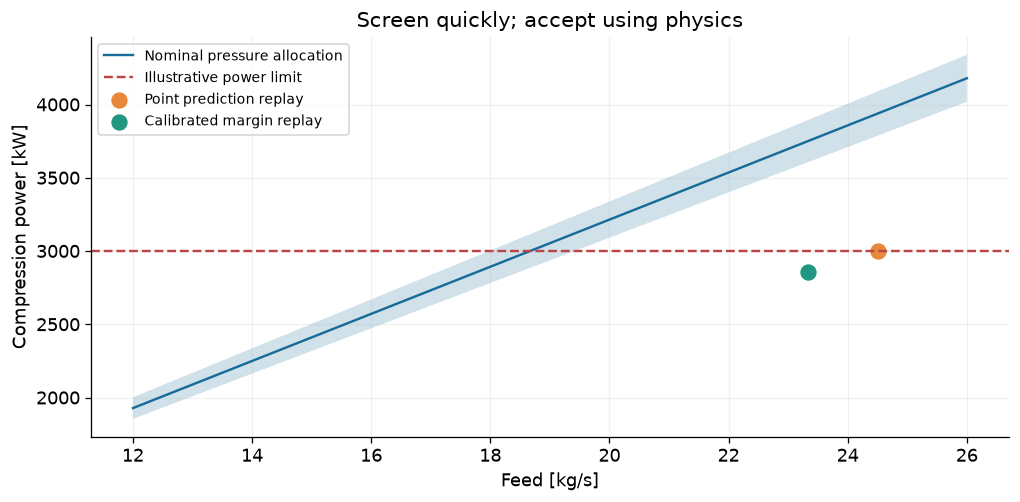

In [20]:
flows = np.linspace(12.0, 26.0, 30)
nominal_curve = np.tile(NOMINAL, (len(flows), 1))
nominal_curve[:, 0] = flows
curve_mean, curve_scale = gp_mean_scale(nominal_curve)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(flows, curve_mean[:, 2], label="Nominal pressure allocation")
ax.fill_between(
    flows,
    curve_mean[:, 2] - conformal_q * curve_scale[:, 2],
    curve_mean[:, 2] + conformal_q * curve_scale[:, 2],
    alpha=0.2,
)
ax.axhline(POWER_LIMIT, color="#bb4545", linestyle="--", label="Illustrative power limit")
for label, (point, result, feasible) in recommended.items():
    ax.scatter(
        point[0], result.y[2], s=85, marker="o" if feasible else "x", label=label + " replay"
    )
ax.set(
    xlabel="Feed [kg/s]",
    ylabel="Compression power [kW]",
    title="Screen quickly; accept using physics",
)
ax.legend(fontsize=9)
fig.tight_layout()
save_show("11_optimization")

The optimization points use their own separator and interstage pressures, so they need not fall on
the nominal-pressure curve. The table is the decision evidence: actual power, temperature and liquid
recovery, plus an explicit feasibility flag. This numerical search is not proof of a global optimum;
an engineering implementation would add compressor-map, separator, exchanger and utility constraints
and perform local enrichment around the active limits.

## 14. Dynamic surrogate: why random row splitting is misleading

A steady surrogate contains no inventory or time scale. Here it supplies equilibrium gas rate and
power targets to a **declared reduced dynamic model** with first-order lags. This is a dynamic
surrogate lesson, not native NeqSim vessel/shaft dynamics. NeqSim supplies each steady target.

$$y_{t+\Delta t}=y_t+\left(1-e^{-\Delta t/\tau}\right)\left(y_{\mathrm{ss}}(u_t)-y_t\right)$$

$y$ is gas rate (kg/s) or shaft power (kW), $\Delta t=5$ s, and time constants are 25 s and 12 s.
We train a nonlinear autoregressive model with exogenous inputs (NARX) on complete training
trajectories, then hold out complete new trajectories and compare one-step error with recursive
rollout. The lag model and its time constants are assumptions; an operating digital twin needs
identified or mechanistically validated dynamics and temporal/conformal methods suited to dependence.

,held-out trajectory,mode,gas RMSE kg/s,power RMSE kW
0,6,One-step,0.0004,1.8047
1,6,Recursive,0.0020,4.8747
2,7,One-step,0.0004,1.6690
3,7,Recursive,0.0018,4.6059


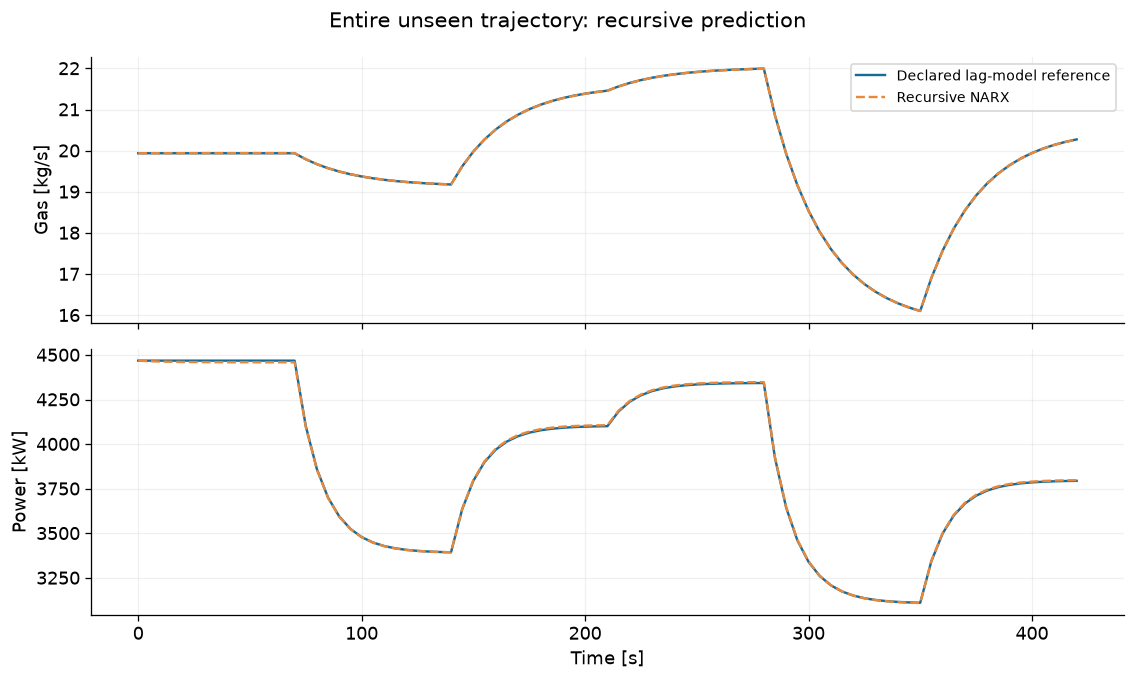

In [21]:
DT = 5.0
TIME_CONSTANTS = np.array([25.0, 12.0])
LAG_GAIN = 1.0 - np.exp(-DT / TIME_CONSTANTS)


def create_trajectory(seed, segments=6, steps_per_segment=14):
    generator = np.random.default_rng(seed)
    setpoints = np.tile(NOMINAL, (segments, 1))
    setpoints[:, 0] = generator.uniform(13.0, 25.0, segments)
    setpoints[:, 1] = generator.uniform(27.0, 43.0, segments)
    targets = np.array([r.y[[0, 2]] for r in simulate_design(setpoints, f"trajectory-{seed}")])
    inputs = np.repeat(setpoints, steps_per_segment, axis=0)
    steady = np.repeat(targets, steps_per_segment, axis=0)
    states = [steady[0].copy()]
    for target in steady:
        states.append(states[-1] + LAG_GAIN * (target - states[-1]))
    return inputs, np.array(states), steady


trajectories = [create_trajectory(SEED + 200 + i) for i in range(8)]
state_scale = np.array([20.0, 3500.0])


def dynamic_features(inputs, states):
    controls = (inputs[:, [0, 1]] - LOW[[0, 1]]) / (HIGH - LOW)[[0, 1]]
    return np.column_stack([controls, states / state_scale])


train_dynamic_x = np.vstack([dynamic_features(u, y[:-1]) for u, y, _ in trajectories[:6]])
train_dynamic_y = np.vstack([y[1:] / state_scale for _, y, _ in trajectories[:6]])
narx = make_pipeline(PolynomialFeatures(2), Ridge(alpha=1e-5))
narx.fit(train_dynamic_x, train_dynamic_y)
dynamic_rows = []
rollouts = []
for index, (inputs, truth, steady) in enumerate(trajectories[6:], start=6):
    one_step = narx.predict(dynamic_features(inputs, truth[:-1])) * state_scale
    rollout = [truth[0].copy()]
    for point in inputs:
        estimate = narx.predict(dynamic_features(point[None, :], np.array([rollout[-1]])))[0]
        rollout.append(estimate * state_scale)
    rollout = np.array(rollout)
    assert np.isfinite(rollout).all()
    rollouts.append(rollout)
    for mode, estimate in [("One-step", one_step), ("Recursive", rollout[1:])]:
        errors = np.sqrt(np.mean((estimate - truth[1:]) ** 2, axis=0))
        dynamic_rows.append([index, mode, *errors])
show_table(
    pd.DataFrame(
        dynamic_rows,
        columns=[
            "held-out trajectory",
            "mode",
            "gas RMSE kg/s",
            "power RMSE kW",
        ],
    )
)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
inputs, truth, steady = trajectories[6]
time_axis = np.arange(len(truth)) * DT
for axis, output_index, unit in zip(axes, [0, 1], ["kg/s", "kW"]):
    axis.plot(time_axis, truth[:, output_index], label="Declared lag-model reference")
    axis.plot(time_axis, rollouts[0][:, output_index], "--", label="Recursive NARX")
    axis.set_ylabel(f"{'Gas' if output_index == 0 else 'Power'} [{unit}]")
axes[0].legend(fontsize=9)
axes[1].set_xlabel("Time [s]")
fig.suptitle("Entire unseen trajectory: recursive prediction")
fig.tight_layout()
save_show("12_dynamics")

One-step prediction receives the true preceding state; recursive deployment receives its own previous
prediction. The latter is the relevant stability and accumulated-error test. Randomly shuffling
adjacent time rows would put nearly identical operating history in training and testing, overstating
performance. No claim of transient separator or anti-surge validation follows from this lag experiment.

## 15. Native NeqSim surrogate registry and guarded inference

NeqSim includes `SurrogateModelRegistry`, a Java interface for prediction, metadata, and physics
fallback. The following JProxy connects the trained Python GP to that actual interface. The full
native `ProcessSystem` remains the fallback and the reference for accepted optimization decisions.

The registry's current metadata range check is not a complete input/output schema validator.
The adapter therefore enforces input shape, finite values, training support, output shape, finite
values and coarse physical conditions explicitly. Invalid requests raise an error. Valid but
unsupported requests run NeqSim. A Python-backed proxy is not a portable Java-serialized model;
export preprocessing and model artifacts separately, or qualify a dedicated Java/ONNX inference
implementation before deployment.

In [22]:
Registry = jpype.JClass("neqsim.process.ml.surrogate.SurrogateModelRegistry")
Metadata = jpype.JClass("neqsim.process.ml.surrogate.SurrogateModelRegistry$SurrogateMetadata")
Interface = "neqsim.process.ml.surrogate.SurrogateModelRegistry$SurrogateModel"
DoubleArray = jpype.JArray(jpype.JDouble)
registry = Registry.getInstance()
metadata = Metadata()
metadata.setInputBounds(DoubleArray(LOW.tolist()), DoubleArray(HIGH.tolist()))
metadata.setModelType("Python GP with explicit validation")
metadata.setTrainingDataSource("NeqSim " + NEQSIM_SOURCE_REF)
route_counts = {"surrogate": 0, "physics": 0}


class PlantSurrogate:
    def predict(self, values):
        point = np.array(values, dtype=float)
        supported, _ = domain_gate(point)
        if not supported[0]:
            raise ValueError("Outside qualified training support")
        prediction = predict_model("GP", point)[0]
        if prediction.shape != (5,) or not np.isfinite(prediction).all():
            raise ValueError("Invalid surrogate output schema")
        mass_defect = abs(prediction[0] + prediction[1] - point[0]) / point[0]
        if (prediction[:4] < 0).any() or mass_defect > 0.005:
            raise ValueError("Surrogate physical check failed")
        route_counts["surrogate"] += 1
        return DoubleArray(prediction.tolist())


class PhysicsFallback:
    def apply(self, values):
        route_counts["physics"] += 1
        return DoubleArray(simulate(np.array(values)).y.tolist())


surrogate_proxy = jpype.JProxy(Interface, inst=PlantSurrogate())
fallback_proxy = jpype.JProxy("java.util.function.Function", inst=PhysicsFallback())
model_id = "notebook-3819-gas-plant"
registry.register(model_id, surrogate_proxy, metadata)


def guarded_inference(values):
    point = np.asarray(values, dtype=float)
    if point.shape != (7,) or not np.isfinite(point).all():
        raise ValueError("Invalid request; seven finite values required")
    before = route_counts.copy()
    prediction = np.array(
        registry.predictWithFallback(
            model_id,
            DoubleArray(point.tolist()),
            fallback_proxy,
        )
    )
    route = "physics" if route_counts["physics"] > before["physics"] else "surrogate"
    assert prediction.shape == (5,) and np.isfinite(prediction).all()
    return prediction, route


registry_rows = []
for label, point in [("Training support", X_train[0]), ("Shift request", X_ood[0])]:
    prediction, route = guarded_inference(point)
    registry_rows.append([label, route, prediction[2]])
for bad in [[1.0, 2.0], [np.nan] * 7]:
    try:
        guarded_inference(bad)
        raise AssertionError("Malformed request was accepted")
    except ValueError:
        pass
show_table(pd.DataFrame(registry_rows, columns=["request", "execution route", "power kW"]))
print("Guard tests passed: wrong dimensions and NaN rejected; shift routed to physics.")
print("Route counters:", route_counts)
_ = registry.unregister(model_id)

Guard tests passed: wrong dimensions and NaN rejected; shift routed to physics.
Route counters: {'surrogate': 1, 'physics': 1}


,request,execution route,power kW
0,Training support,surrogate,1792.4556
1,Shift request,physics,1975.7992


A successful fallback means a calculation was obtained; it does not mean the surrogate was trusted.
Keep route, model version, source hash, input units, uncertainty, and native acceptance status in the
response contract. For concurrent services use independent process instances and qualify JVM/Python
threading; this notebook intentionally runs serially.

## 16. Honest performance accounting and break-even use

Separate process construction plus solution, serial one-request inference, vectorized inference,
training, and the cost of generating labels. JIT warm-up is excluded from the repeated comparison.
No universal GPU speedup or paper-reported speedup is imported into this experiment.

$$N_{\mathrm{break\ even}}=\frac{t_{\mathrm{data}}+t_{\mathrm{fit}}}{t_{\mathrm{native}}-t_{\mathrm{surrogate}}}$$

Times are seconds and $N$ is the number of future accepted surrogate evaluations. The formula assumes
fixed costs, similar native-case cost, no retraining and no fallback. A useful production estimate
must also include validation, support checks, fallback frequency, data transfer and model maintenance.

Labels: 13.60 s; GP fit/selection: 0.01 s
Simplified single-request break-even: 239 future evaluations
Excludes calibration/test labels and other study overhead; not a full project payback claim.


,path,median ms/case,speed relative to native
0,Native build + solve,57.051,1.000
1,GP single request,0.181,315.725
2,GP vectorized (batch 16),0.012,4811.594


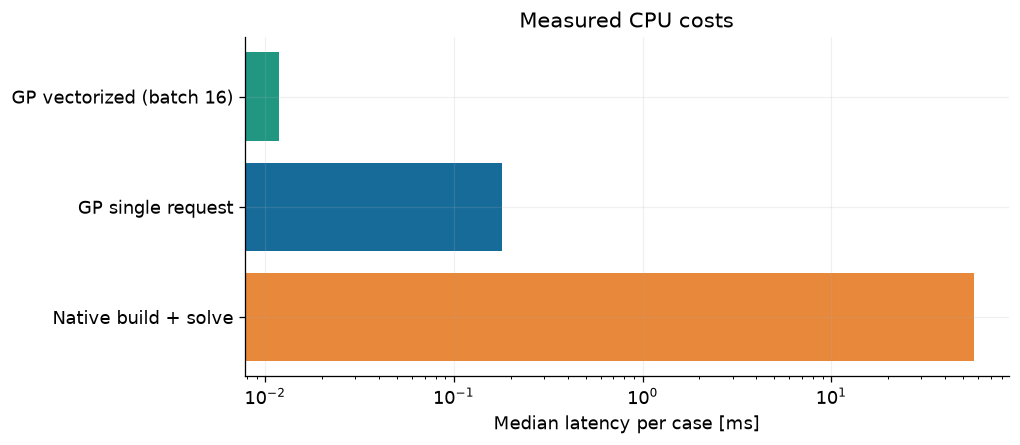

In [23]:
benchmark_points = X_test[:16].copy()
_ = simulate(benchmark_points[0])
_ = predict_model("GP", benchmark_points)
native_times = []
single_times = []
batch_times = []
for repeat in range(5):
    started = time.perf_counter()
    for point in benchmark_points:
        simulate(point)
    native_times.append((time.perf_counter() - started) / len(benchmark_points))
    started = time.perf_counter()
    for point in benchmark_points:
        predict_model("GP", point)
    single_times.append((time.perf_counter() - started) / len(benchmark_points))
    started = time.perf_counter()
    for _ in range(30):
        predict_model("GP", benchmark_points)
    batch_times.append((time.perf_counter() - started) / (30 * len(benchmark_points)))
native_seconds = float(np.median(native_times))
single_seconds = float(np.median(single_times))
batch_seconds = float(np.median(batch_times))
gp_fit_seconds = fit_seconds["GP"]
training_data_cost = sum(r.seconds for r in DATA["train"])
break_even = (training_data_cost + gp_fit_seconds) / max(native_seconds - single_seconds, 1e-12)
benchmark = pd.DataFrame(
    {
        "path": ["Native build + solve", "GP single request", "GP vectorized (batch 16)"],
        "median ms/case": np.array([native_seconds, single_seconds, batch_seconds]) * 1000,
        "speed relative to native": native_seconds
        / np.array([native_seconds, single_seconds, batch_seconds]),
    }
)
show_table(benchmark, decimals=3)
print(f"Labels: {training_data_cost:.2f} s; GP fit/selection: {gp_fit_seconds:.2f} s")
print(f"Simplified single-request break-even: {break_even:.0f} future evaluations")
print(
    "Excludes calibration/test labels and other study overhead; not a full project payback claim."
)
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(benchmark["path"], benchmark["median ms/case"], color=["#e8883a", "#176b99", "#219781"])
ax.set(xscale="log", xlabel="Median latency per case [ms]", title="Measured CPU costs")
fig.tight_layout()
save_show("13_performance")

Batch throughput and single-request latency answer different questions. An online service may mostly
use the single-request path; an optimizer can often batch candidate points. These timings include
fresh native construction, so a reused or optimized NeqSim process could reduce the baseline cost.
The notebook does not imply that every large process will obtain the measured speed ratio.

## 17. Reusable artifacts, acceptance record and research directions

The model card records units, domain, composition family, topology, source and dependency versions,
metrics, calibration method and limitations. CSV/JSON files allow another tool to consume the results.
A `joblib` file is only for a trusted Python environment with compatible versions; never load an
untrusted pickle. The Java registry proxy is recreated from Python rather than serialized.

**For a larger process:** construct a directed equipment graph with stream states as interfaces;
partition at expensive units; encode component rates, pressure and enthalpy; preserve mixing and
split balances analytically; train local models over admissible states; solve recycles with residual
monitoring and fallback; propagate uncertainty through the whole graph; and qualify topology changes
with graph-held-out tests. Include failure classification so the optimizer cannot learn to exploit
solver failures.

**For a research-grade extension:** compare MLP, GP, gradient-boosted trees and graph modules under
matched simulator budgets and several seeds; jointly fine-tune a differentiable cascade with
component-conserving heads; test phase-boundary and new-composition generalization; add true
rate-based/dynamic target models; and validate against public experimental or plant benchmarks.
Physics losses must use explicit residual scales and units. A small loss is not proof of physical
correctness. Report offline and online costs, failures, constraint violations and calibration under
shift, not only average R².

**Current NeqSim improvement discovered:** the existing surrogate registry needs strict finite-value,
dimension and output-schema validation. The notebook adapter supplies these checks at its boundary;
[issue #3906](https://github.com/equinor/neqsim/issues/3906) provides the native reproducer and acceptance tests.
The registry itself is not changed by this notebook.

In [24]:
model_card = {
    "name": "NeqSim advanced gas-plant surrogate tutorial",
    "version": "1.0",
    "provenance": provenance,
    "seed": SEED,
    "inputs": FEATURES,
    "lower_bounds": LOW.tolist(),
    "upper_bounds": HIGH.tolist(),
    "outputs": dict(zip(TARGETS, TARGET_UNITS)),
    "base_components": COMPONENTS,
    "base_mole_fractions": BASE_Z.tolist(),
    "topology": "10 units, 3 separation blocks, no recycle",
    "dataset_counts": {label: len(results) for label, results in DATA.items()},
    "failures": failures,
    "conformal": {
        "alpha": ALPHA,
        "rank": rank,
        "q": conformal_q,
        "method": "max-score simultaneous split conformal",
    },
    "maximum_balance_residuals": dataset[
        ["mass_residual", "component_residual", "energy_residual"]
    ]
    .max()
    .to_dict(),
    "test_metrics": metrics.to_dict(orient="records"),
    "joint_coverage": coverage.to_dict(orient="records"),
    "optimization": optimization.to_dict(orient="records"),
    "accepted_decisions": accepted_frame.to_dict(orient="records"),
    "timings": benchmark.to_dict(orient="records"),
    "figures": figure_files,
    "training_warnings": training_warnings,
    "limitations": [
        "Synthetic dry sweet composition family; no experimental validation",
        "Fixed topology, efficiencies and outlet specifications; no surge/map/UA constraints",
        "GP and ensemble uncertainty excludes EOS and measurement uncertainty",
        "Conformal coverage assumes exchangeability, not adaptive optimizer-selected points",
        "SRK/PR experiment is model discrepancy, not established fidelity or cost hierarchy",
        "Dynamic section uses declared lag dynamics, not native equipment transients",
        "Single acquisition seed; no universal active-learning improvement claim",
    ],
}
(OUT / "model_card.json").write_text(json.dumps(model_card, indent=2))
joblib.dump(
    {
        "gp": models["GP"],
        "response_scale": response_scale,
        "ensemble": ensemble,
        "modules": module_models,
        "low": LOW,
        "high": HIGH,
        "features": FEATURES,
        "targets": TARGETS,
    },
    OUT / "trusted_python_models.joblib",
)
optimization.to_csv(OUT / "optimization_replay.csv", index=False)
accepted_frame.to_csv(OUT / "accepted_decisions.csv", index=False)
coverage.to_csv(OUT / "coverage.csv", index=False)
active_frame.to_csv(OUT / "active_learning.csv", index=False)
interface_frame.to_csv(OUT / "module_interface_errors.csv", index=False)
import shutil

archive = Path(shutil.make_archive("neqsim_ml_results", "zip", OUT))
show_table(pd.DataFrame({"file": sorted(p.name for p in OUT.iterdir() if p.is_file())}))
print("Created:", archive.resolve())
print("Model card includes provenance, splits, balances, scores, limits and accepted decisions.")
gp_power_rmse = float(
    metrics.loc[
        (metrics["model"] == "GP") & (metrics["target"] == "power_kW"),
        "RMSE",
    ].iloc[0]
)
display(
    Markdown(
        f"**Computed study findings.** The GP achieved a held-out power RMSE of "
        f"**{gp_power_rmse:.2f} kW**. Simultaneous interval coverage was "
        f"**{coverage.iloc[0]['jointly covered']}/{coverage.iloc[0]['n']}** on IID tests "
        f"and **{coverage.iloc[1]['jointly covered']}/{coverage.iloc[1]['n']}** under shift. "
        f"The maximum component-balance residual in the native dataset was "
        f"**{dataset['component_residual'].max():.2e}** relative to feed. "
        f"GP single-request speed ratio: **{native_seconds / single_seconds:.0f}×** "
        f"against fresh native build-and-solve. These are results for this case and runtime."
    )
)

Created: /workspace/scratch/3821cb0d6e55/neqsim_ml_results.zip
Model card includes provenance, splits, balances, scores, limits and accepted decisions.


,file
0,01_flowsheet.png
1,02_base_case.png
2,03_design.png
3,04_parity.png
4,05_modular.png
5,06_hybrid.png
6,07_uncertainty.png
7,08_active_learning.png
8,09_multifidelity.png
9,10_interpretation.png


**Computed study findings.** The GP achieved a held-out power RMSE of **5.78 kW**. Simultaneous interval coverage was **102/120** on IID tests and **56/60** under shift. The maximum component-balance residual in the native dataset was **1.58e-12** relative to feed. GP single-request speed ratio: **316×** against fresh native build-and-solve. These are results for this case and runtime.

## 18. Conclusions and exercises

The strongest demonstrated results are **executed simulator data with balance audits**, held-out
prediction scores, exact component conservation of the modular rate mapping, separate shift tests,
and rigorous replay of optimization candidates. Consult the saved numerical outputs to judge which
surrogate works best. No method is declared best in advance.

1. Repeat active learning across five seeds and plot confidence bands versus total simulator calls.
2. Replace modular trees with sigmoid-output neural networks; compare teacher forcing, rollout and
   joint fine-tuning without touching the held-out test data.
3. Expand composition beyond one richness axis and evaluate leave-one-mixture-family-out accuracy.
4. Add a compressor map and finite-UA coolers; remove the exact-throughput scaling assumption and
   measure the resulting sample-complexity change.
5. Add a recycle loop. Compare fixed-point iteration, damping and native NeqSim fallback; monitor
   component and energy residuals at every iteration.
6. Replace the declared lag model with qualified native NeqSim dynamic equipment and split by
   complete disturbances, initial inventories and equipment configurations.
7. Use decision-aware acquisition near active constraints and compare native feasible throughput
   under matched budgets. Recalibrate intervals after model changes using a fresh calibration set.

## References and source scope

1. Zhang, Q., Liu, P., Fang, W., Ni, D., Kong, Y. (2026).
   [MPNet: A modular deep learning process TCAD surrogate modeling framework](https://doi.org/10.1088/1674-4926/25100005).
   *Journal of Semiconductors*, 47, 062302. Semiconductor domain; modular-cascade inspiration only.
2. Bubel et al. (2021).
   [A Modular Approach for Surrogate Modeling of Flowsheets](https://doi.org/10.1002/cite.202100077).
   Modular chemical-process surrogates and connected flowsheets.
3. Lakshminarayanan, Pritzel, Blundell (2017).
   [Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles](https://arxiv.org/abs/1612.01474).
4. Angelopoulos and Bates (2021; revised 2022).
   [A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification](https://arxiv.org/abs/2107.07511).
5. Li et al. (2020).
   [Fourier Neural Operator for Parametric Partial Differential Equations](https://arxiv.org/abs/2010.08895).
6. Lu et al. (2019).
   [DeepONet: Learning nonlinear operators](https://arxiv.org/abs/1910.03193).
7. Peherstorfer, Willcox, Gunzburger (2018).
   [Survey of Multifidelity Methods in Uncertainty Propagation, Inference, and Optimization](https://doi.org/10.1137/16M1082469).
8. [NeqSim ML integration and surrogate registry](https://equinor.github.io/neqsim/process/ml/),
   [source revision](https://github.com/equinor/neqsim/tree/65dd8733383d64618fa002ac8137925482093365),
   [scikit-learn Gaussian processes](https://scikit-learn.org/stable/modules/gaussian_process.html).

**Documentation impact:** this notebook and its README/catalog/maintenance entries add a new advanced
teaching workflow. No NeqSim Java algorithm or public API is modified. Equations, engineering units,
figures, data splits, model assumptions and limitations are documented next to their implementation.